In [2]:
from google.colab import files

uploaded = files.upload()

Saving corrected_medication_logs.csv to corrected_medication_logs.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving diet_logs.csv to diet_logs.csv


In [4]:
from google.colab import files

uploaded = files.upload()

Saving symptoms.csv to symptoms.csv


In [5]:
from google.colab import files

uploaded = files.upload()

Saving medications.csv to medications.csv


In [6]:
from google.colab import files

uploaded = files.upload()

Saving dietPlans.csv to dietPlans.csv


In [7]:
from google.colab import files

uploaded = files.upload()

Saving patients.csv to patients.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Load all relevant tables
med_logs = pd.read_csv('corrected_medication_logs.csv')
diet_logs = pd.read_csv('diet_logs.csv')
symptoms = pd.read_csv('symptoms.csv')
medications = pd.read_csv('medications.csv')
dietPlans = pd.read_csv('dietPlans.csv')
patients = pd.read_csv('patients.csv')

In [10]:
# Convert date columns
med_logs['logged_at'] = pd.to_datetime(med_logs['logged_at'], errors='coerce')
diet_logs['date'] = pd.to_datetime(diet_logs['date'], format='%d-%m-%Y', errors='coerce')
symptoms['dateReported'] = pd.to_datetime(symptoms['dateReported'], format='%d-%m-%Y', errors='coerce')
medications['startDate'] = pd.to_datetime(medications['startDate'], format='%d-%m-%Y', errors='coerce')
medications['endDate'] = pd.to_datetime(medications['endDate'], format='%d-%m-%Y', errors='coerce')

# Map severity to numeric
severity_map = {'mild': 1, 'moderate': 2, 'severe': 3}
symptoms['severity_num'] = symptoms['severity'].map(severity_map)

# Merge medication logs with medication info and patient info
med_logs = med_logs.merge(medications, left_on=['medicationId','patientId'], right_on=['medicationsId','assignedTo'], how='left')
med_logs = med_logs.merge(patients, on='patientId', how='left')

# Merge diet logs with diet plan info and patient info
diet_logs = diet_logs.merge(dietPlans, left_on=['diet_plan','patientId'], right_on=['description','assignedTo'], how='left')
diet_logs = diet_logs.merge(patients, on='patientId', how='left')

# Merge symptoms with patient info
symptoms = symptoms.merge(patients, on='patientId', how='left')

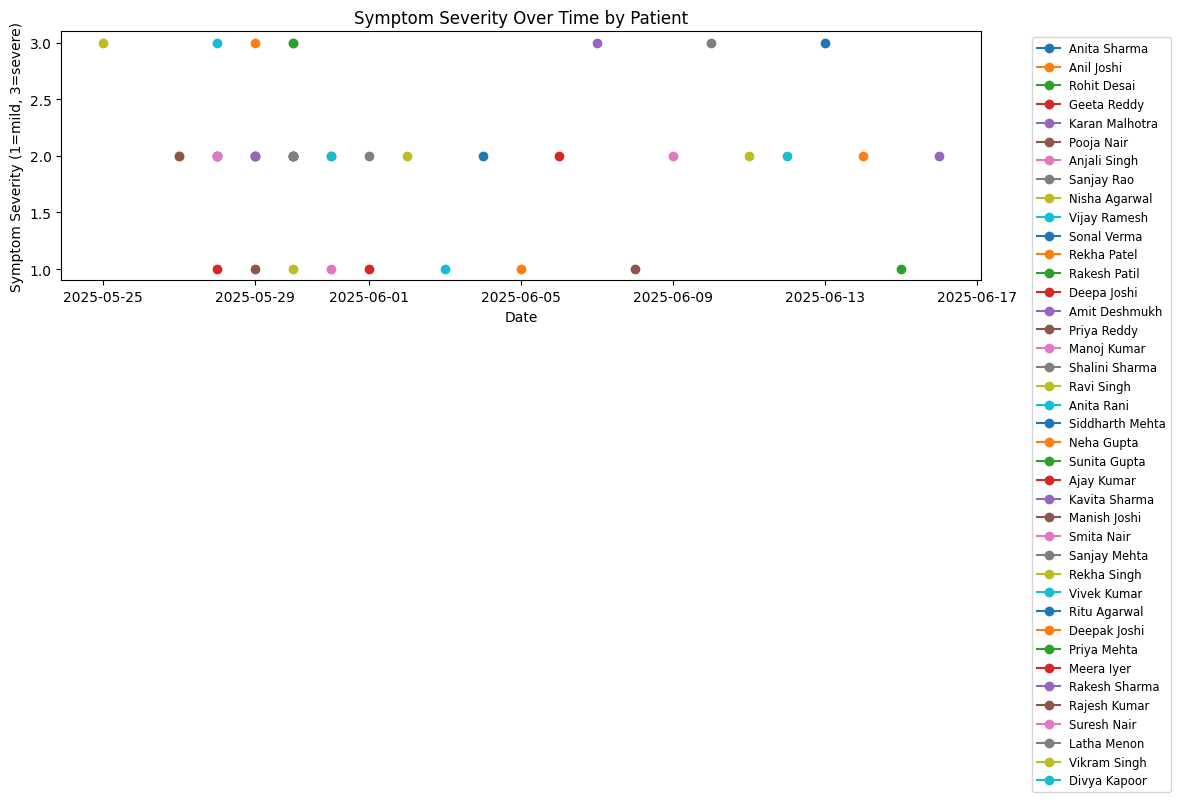

In [11]:
plt.figure(figsize=(12,6))
for pid, group in symptoms.groupby('patientId'):
    plt.plot(group['dateReported'], group['severity_num'], marker='o', label=group['patient_name'].iloc[0])
plt.title('Symptom Severity Over Time by Patient')
plt.xlabel('Date')
plt.ylabel('Symptom Severity (1=mild, 3=severe)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()


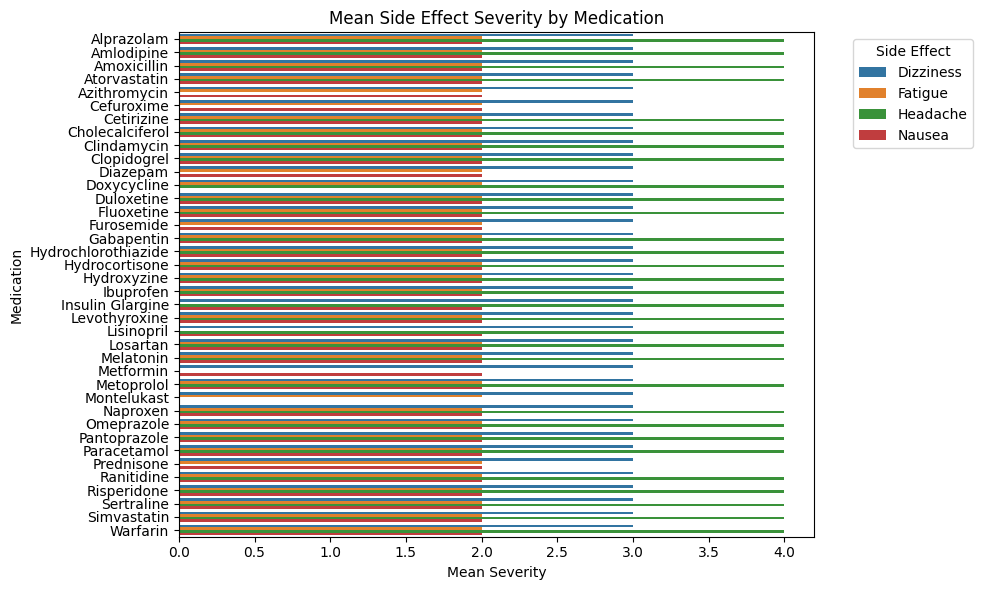

In [12]:
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')
side_effects_summary = med_logs.groupby(['title','side_effects__description']).agg(
    mean_severity=('side_effects__severity','mean'),
    count=('side_effects__severity','count')
).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=side_effects_summary, x='mean_severity', y='title', hue='side_effects__description')
plt.title('Mean Side Effect Severity by Medication')
plt.xlabel('Mean Severity')
plt.ylabel('Medication')
plt.legend(title='Side Effect', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


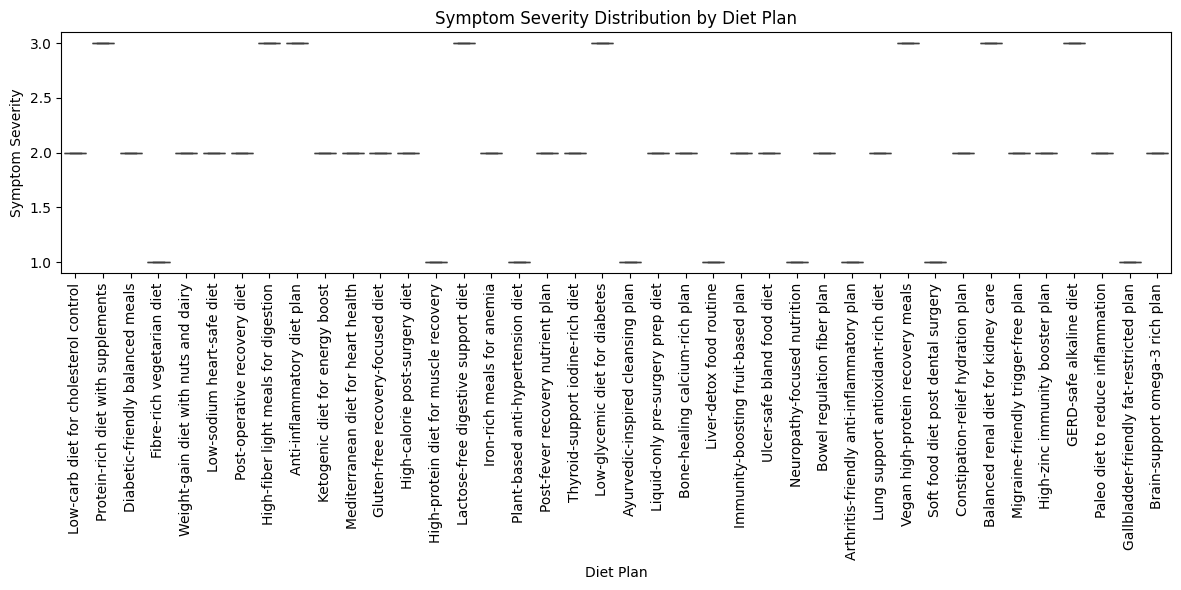

In [13]:
diet_symptom = diet_logs.merge(symptoms, on=['patientId'], how='left')
plt.figure(figsize=(12,6))
sns.boxplot(data=diet_symptom, x='description', y='severity_num')
plt.title('Symptom Severity Distribution by Diet Plan')
plt.xlabel('Diet Plan')
plt.ylabel('Symptom Severity')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


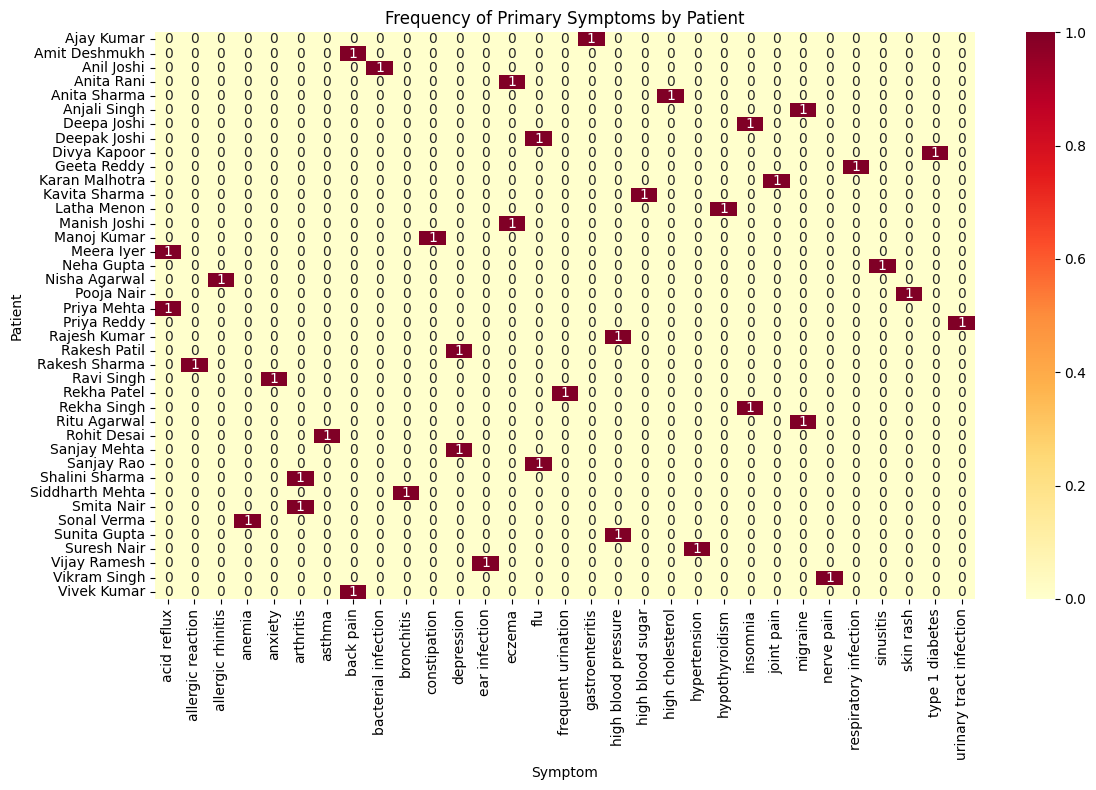

In [14]:
symptom_counts = symptoms.groupby(['patient_name','symptom1']).size().unstack(fill_value=0)
plt.figure(figsize=(12,8))
sns.heatmap(symptom_counts, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Frequency of Primary Symptoms by Patient')
plt.xlabel('Symptom')
plt.ylabel('Patient')
plt.tight_layout()
plt.show()


<ipython-input-20-222091884c44>:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,4))


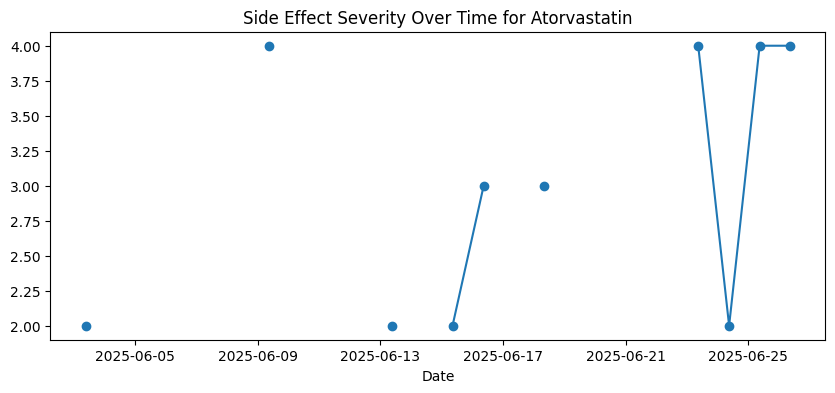

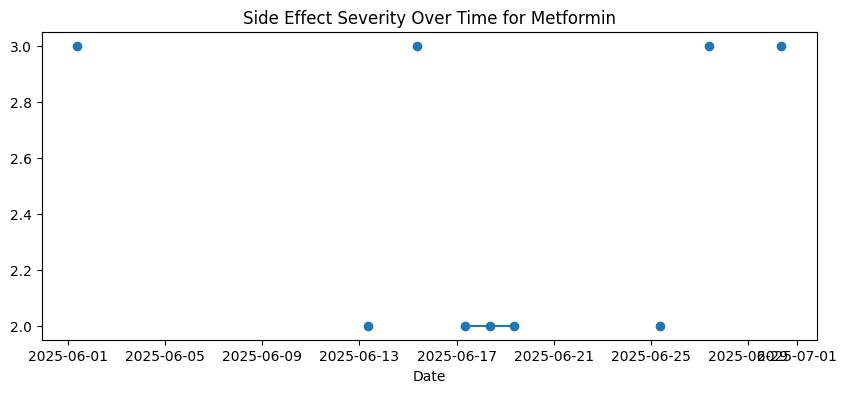

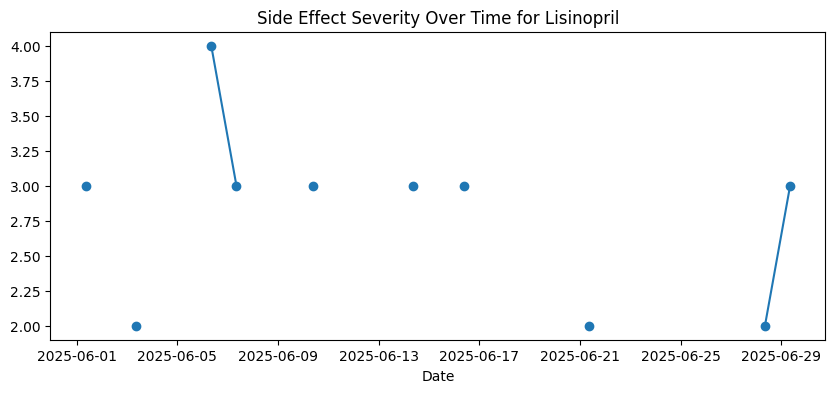

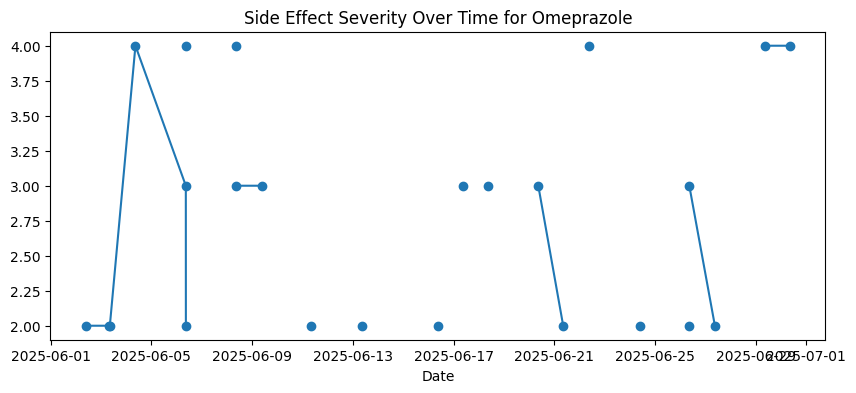

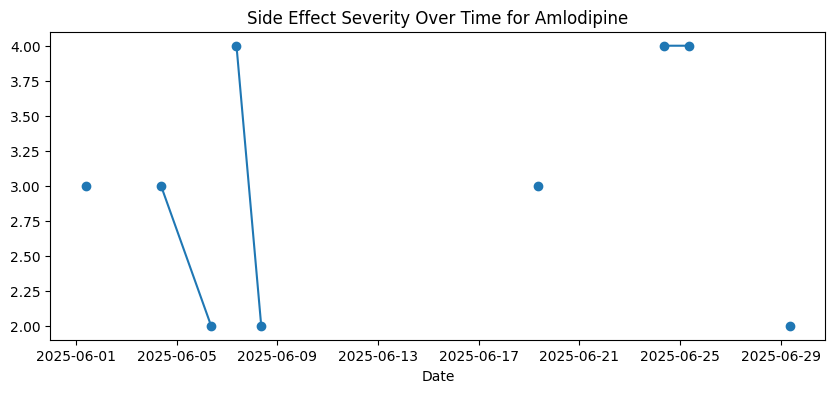

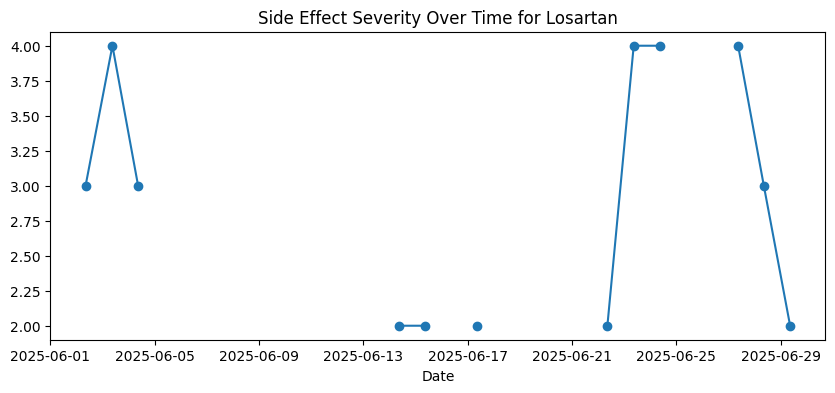

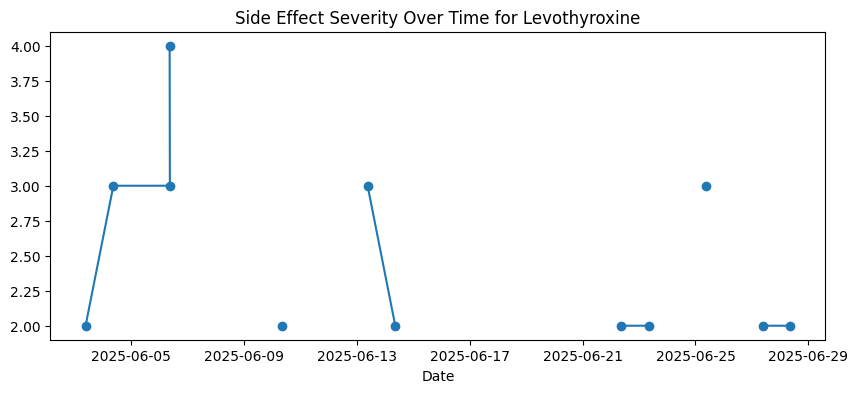

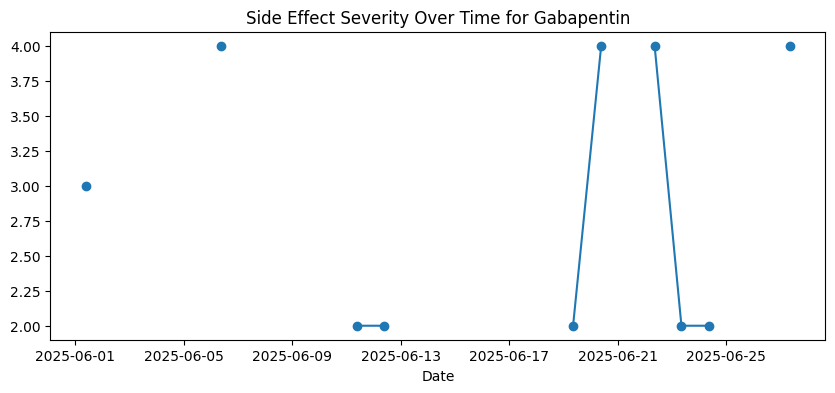

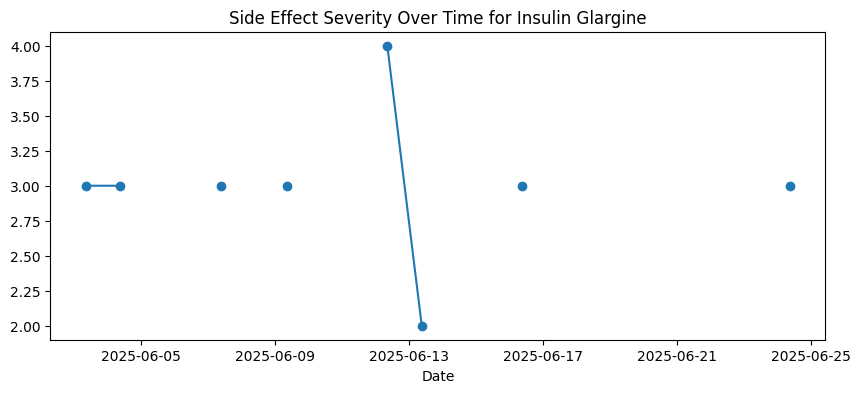

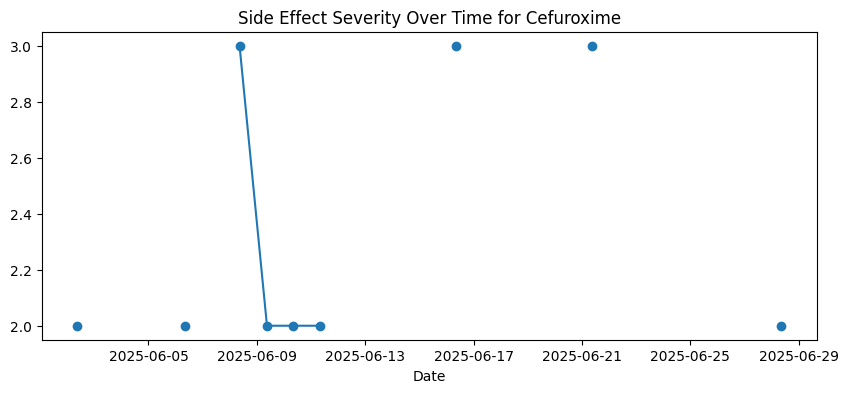

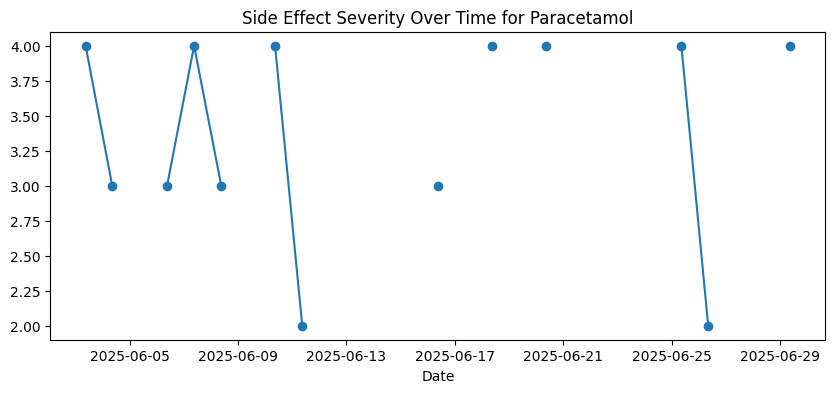

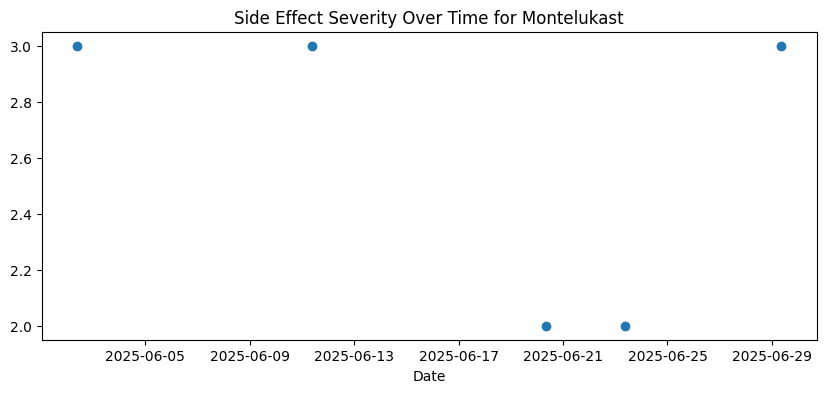

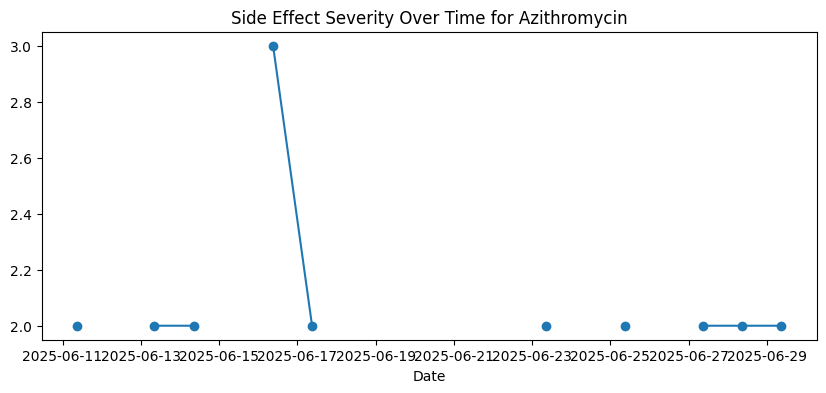

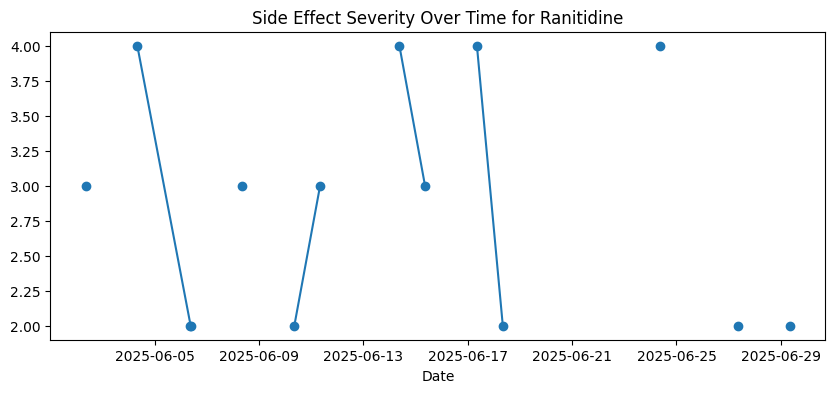

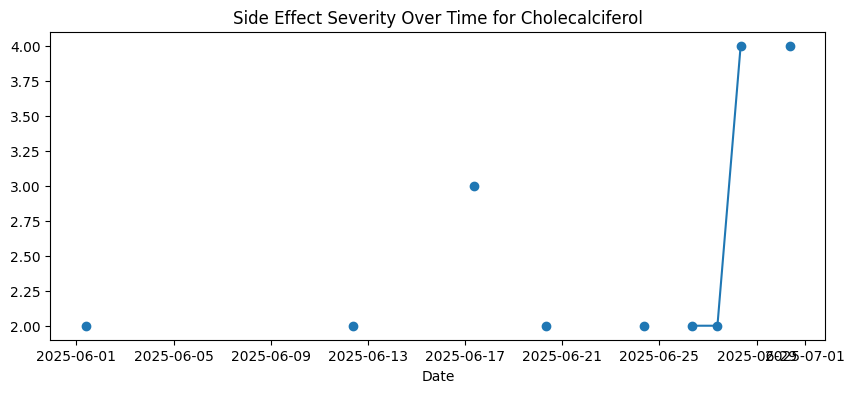

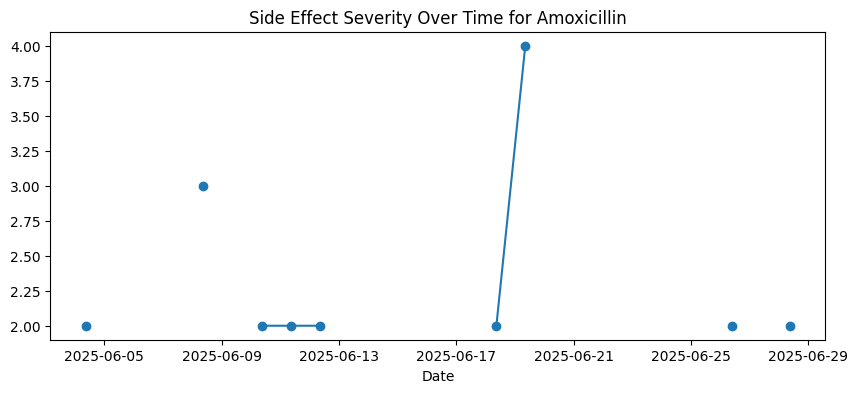

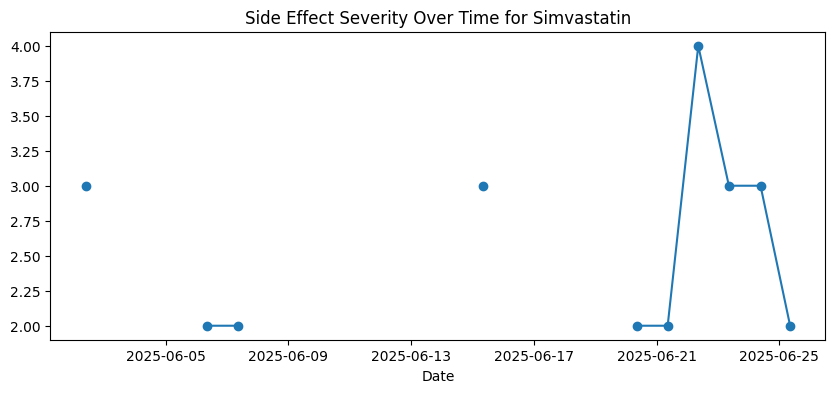

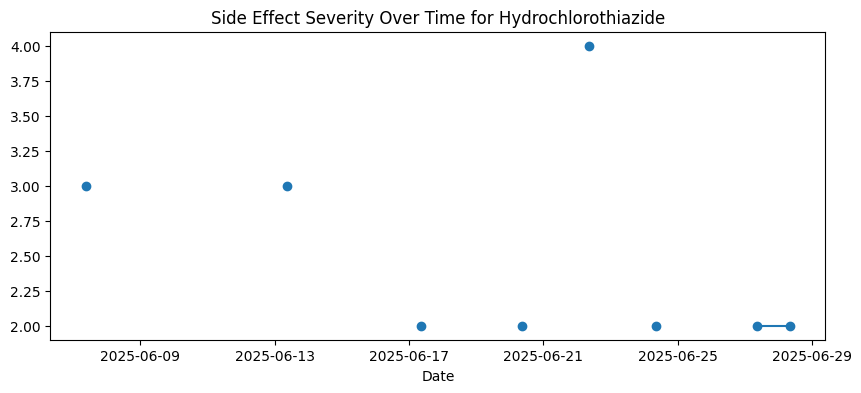

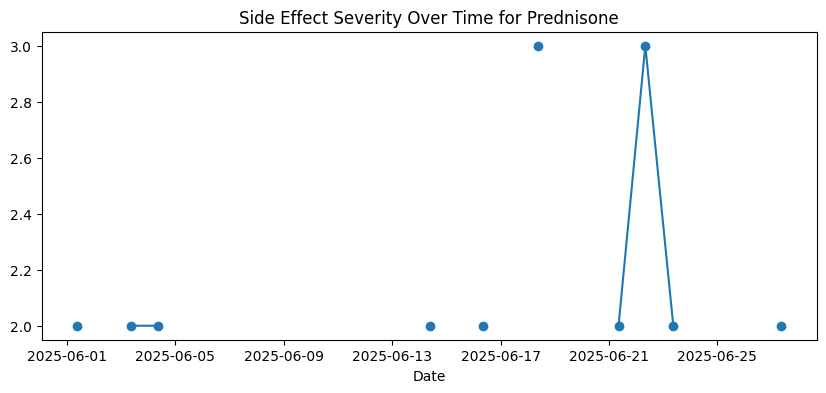

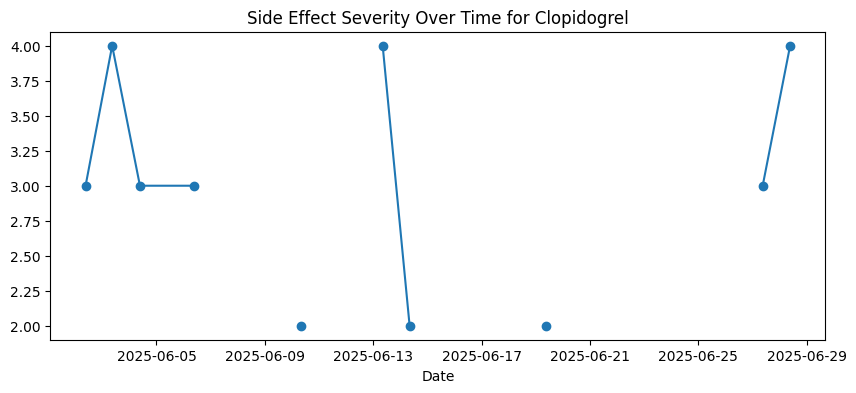

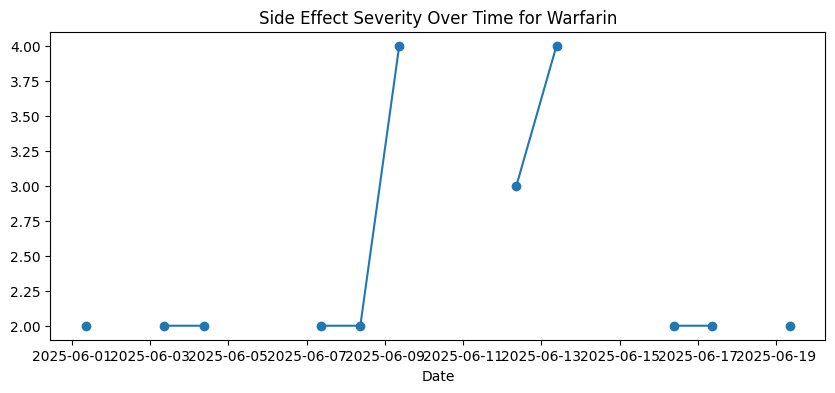

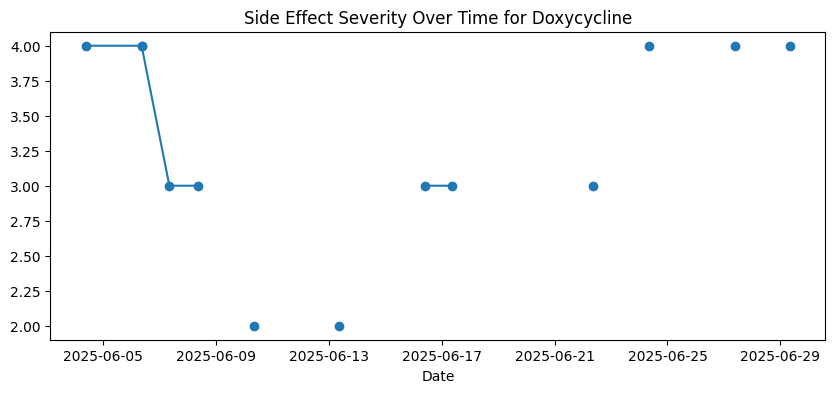

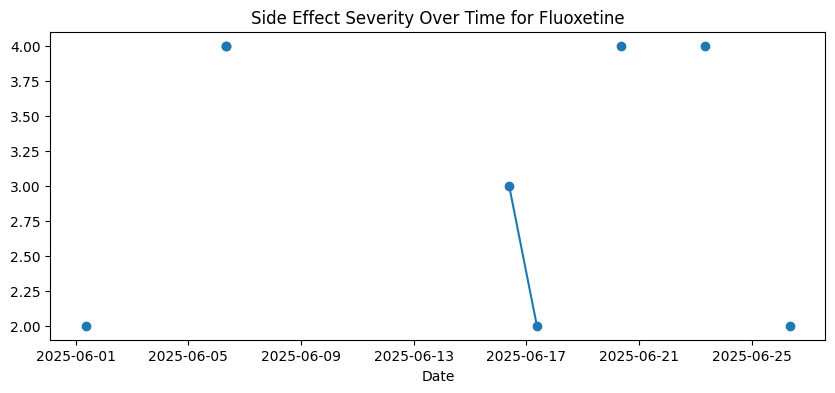

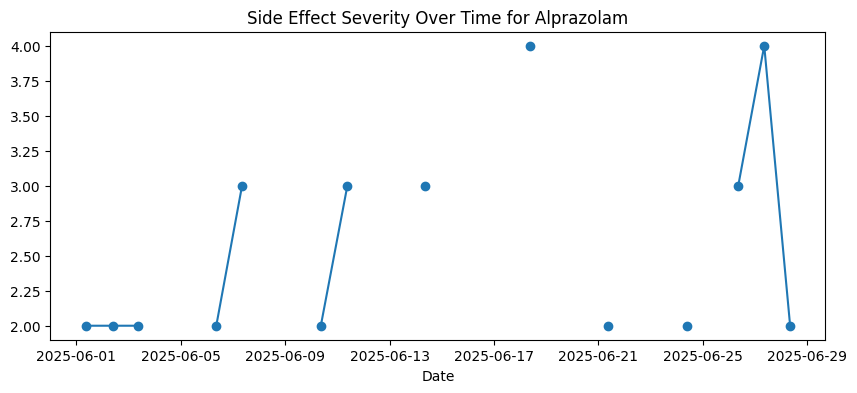

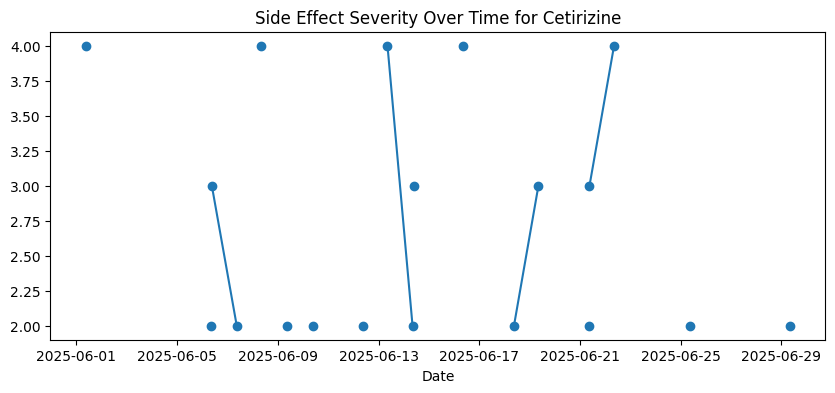

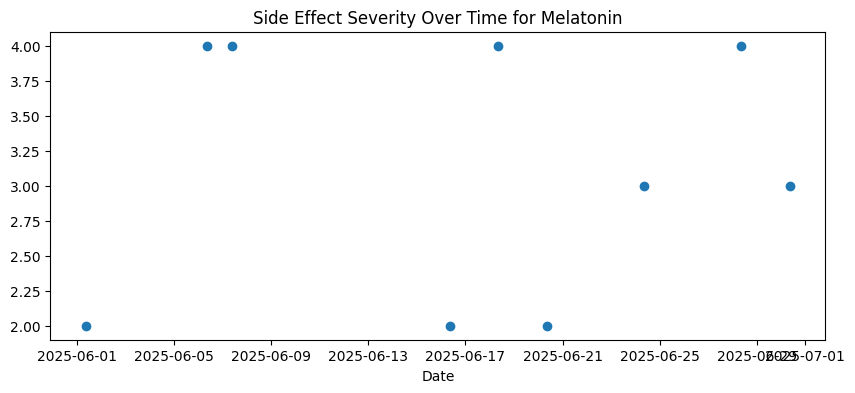

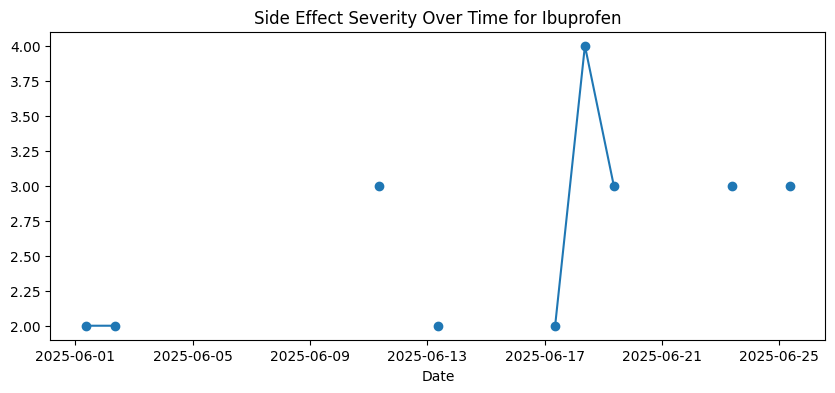

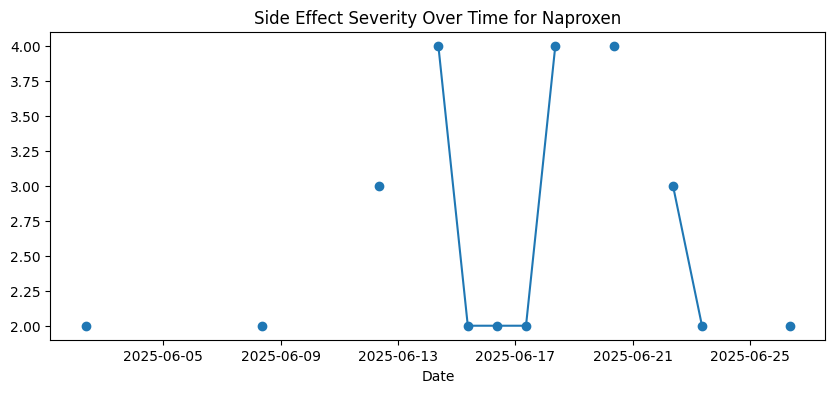

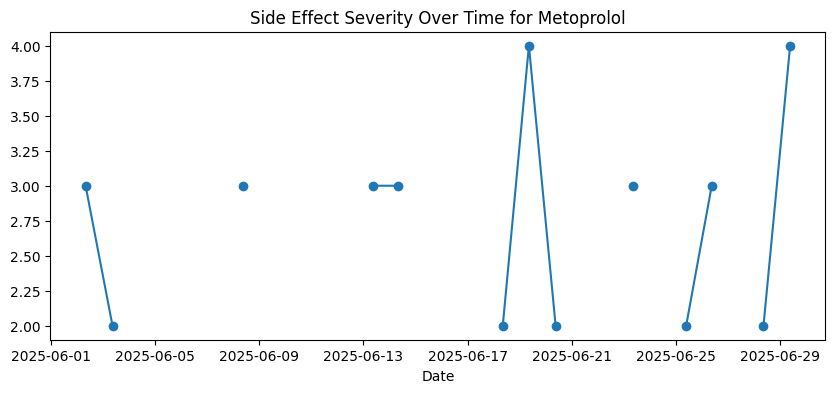

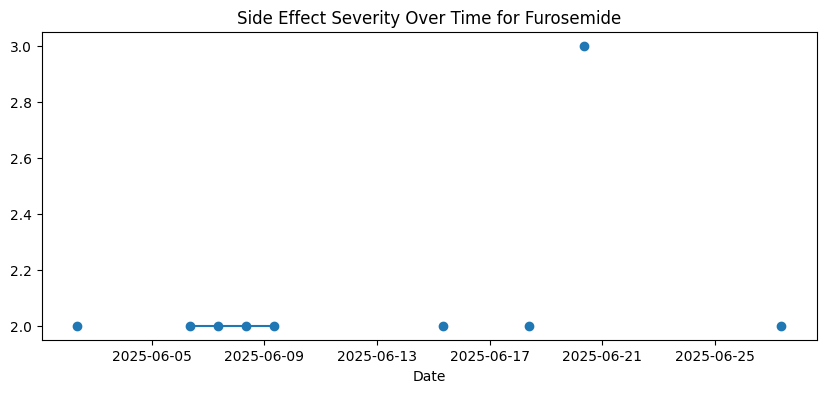

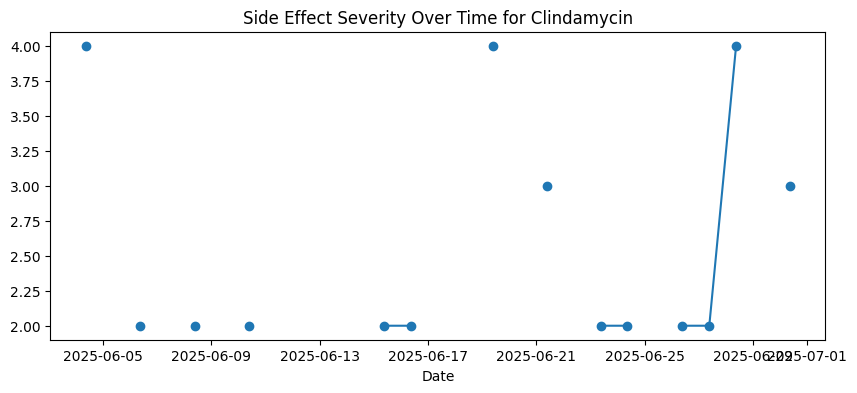

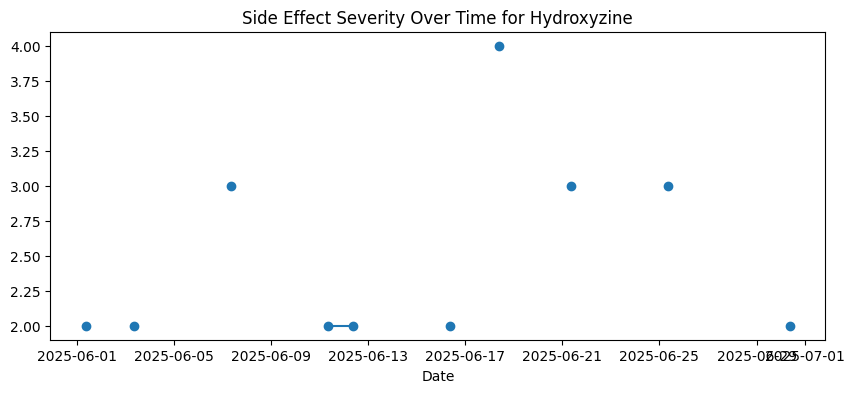

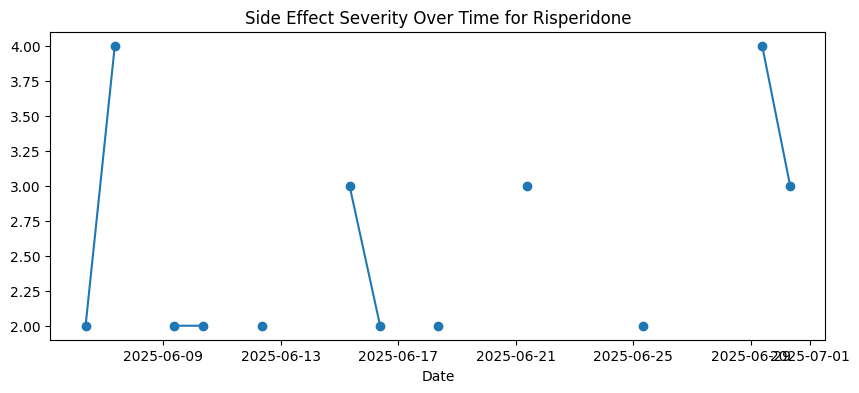

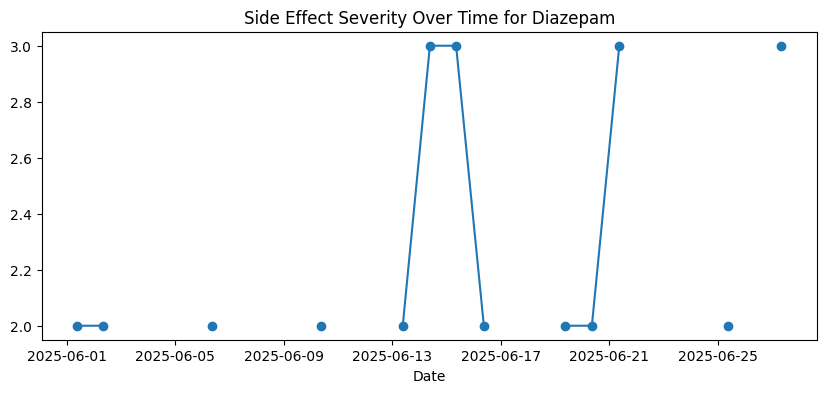

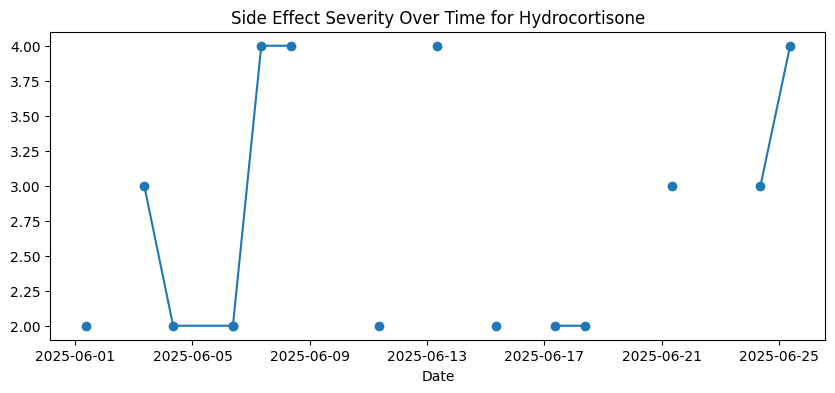

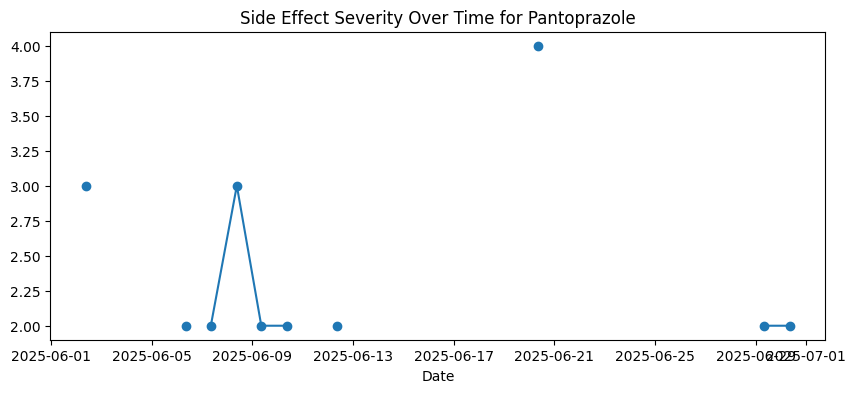

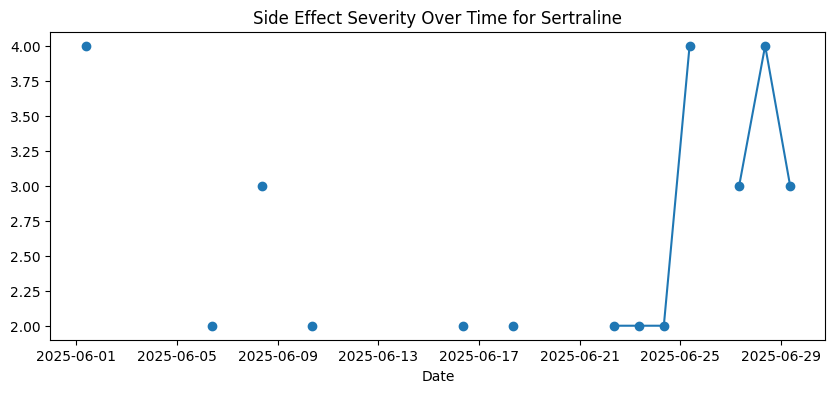

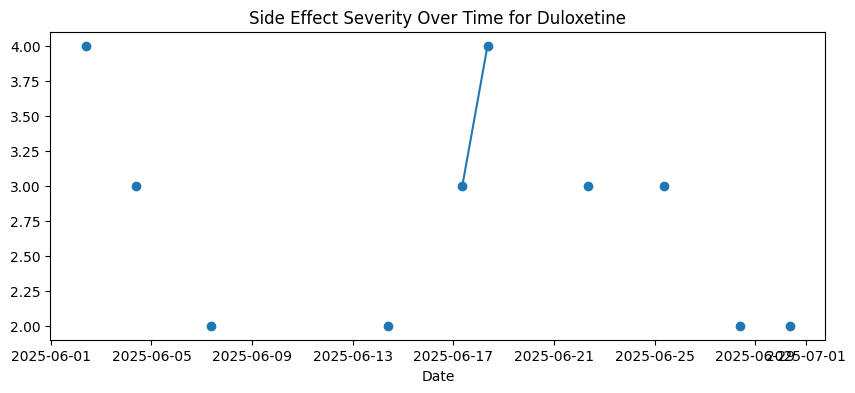

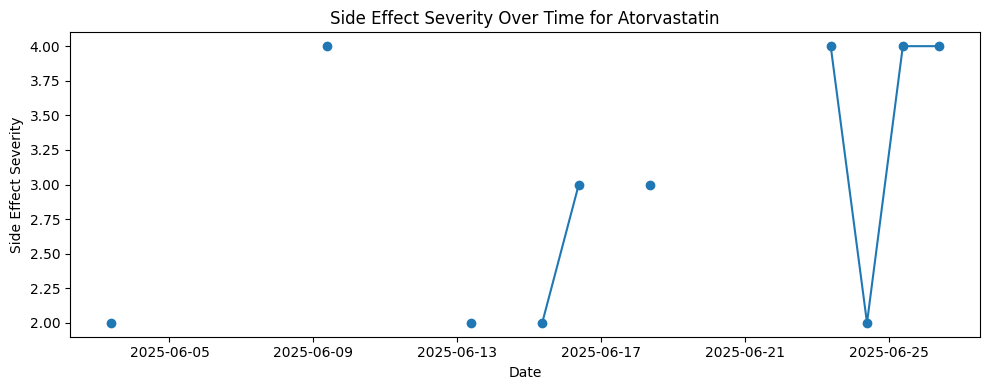

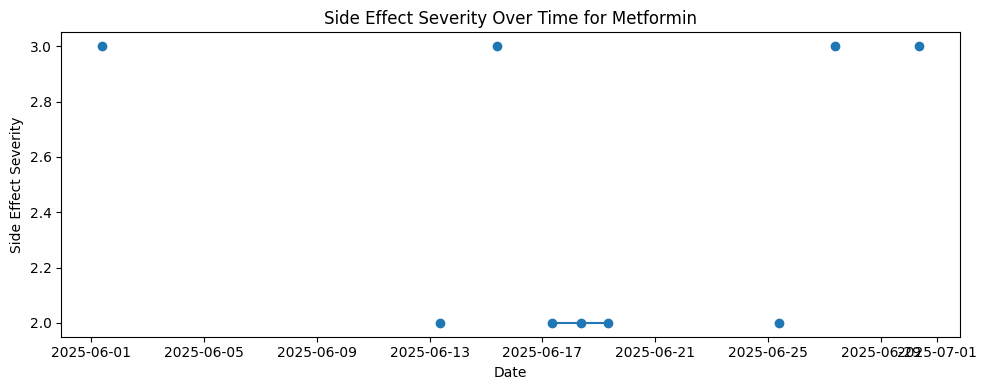

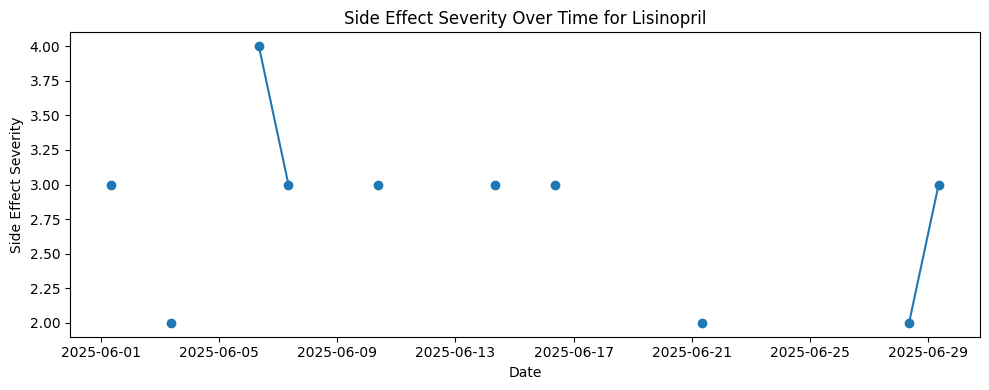

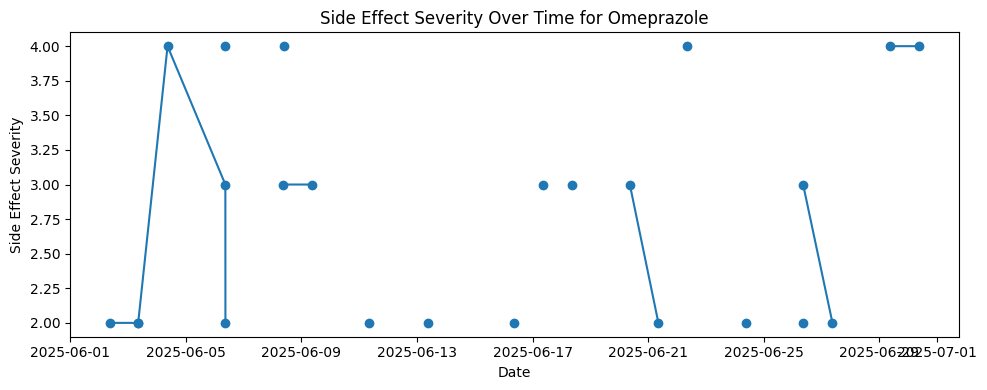

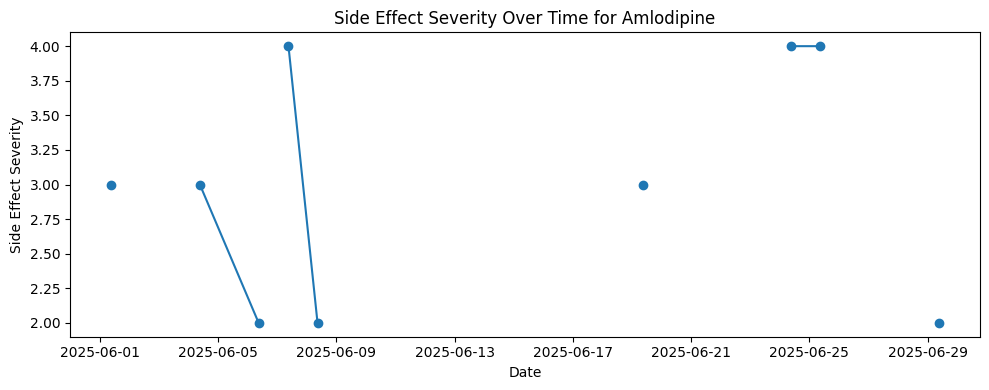

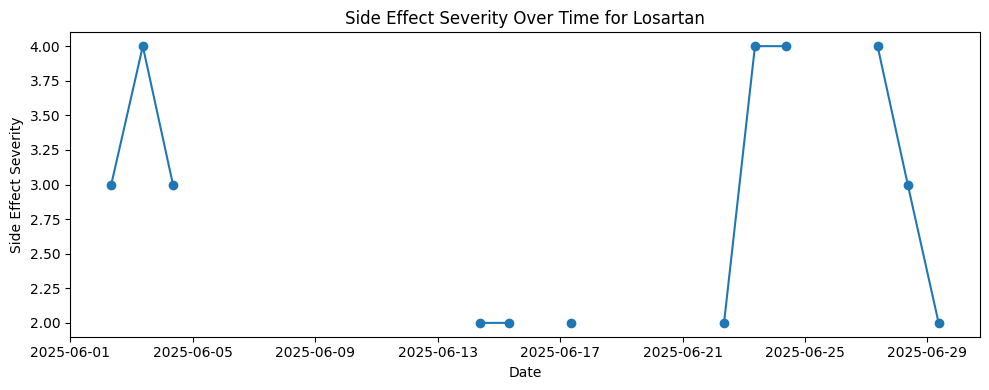

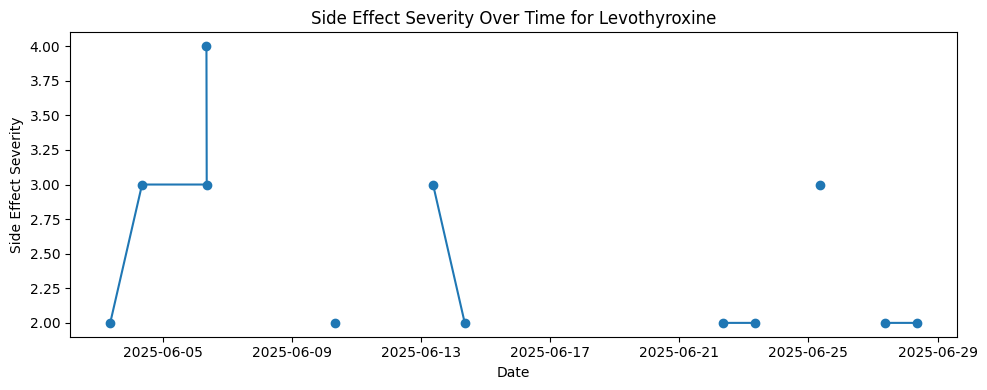

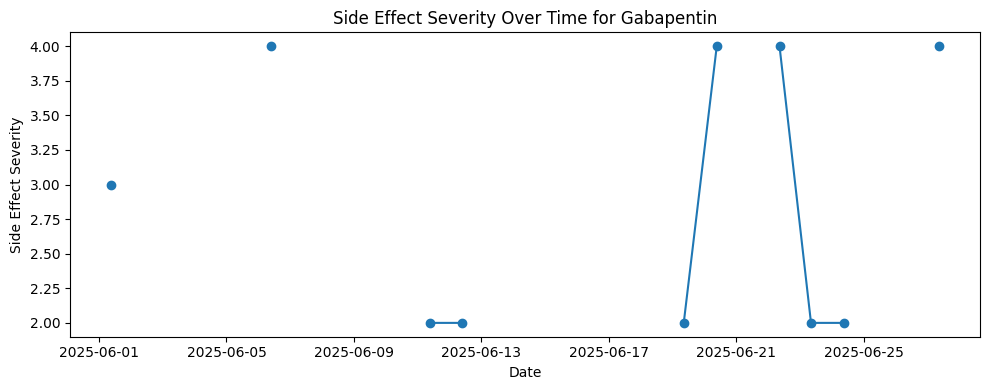

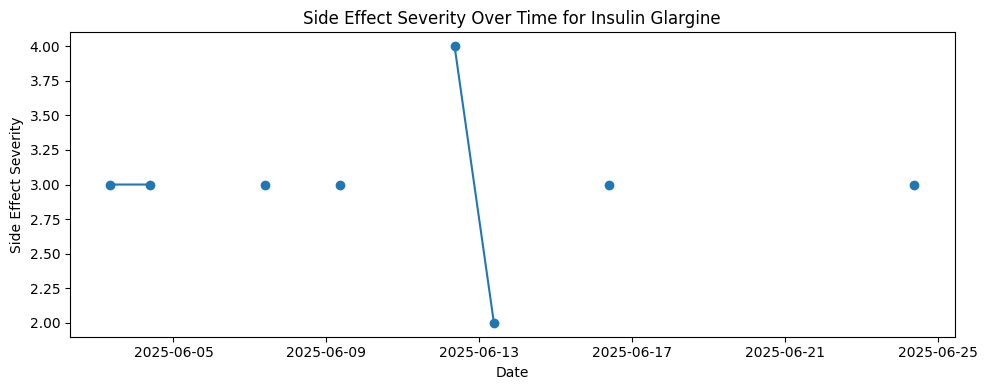

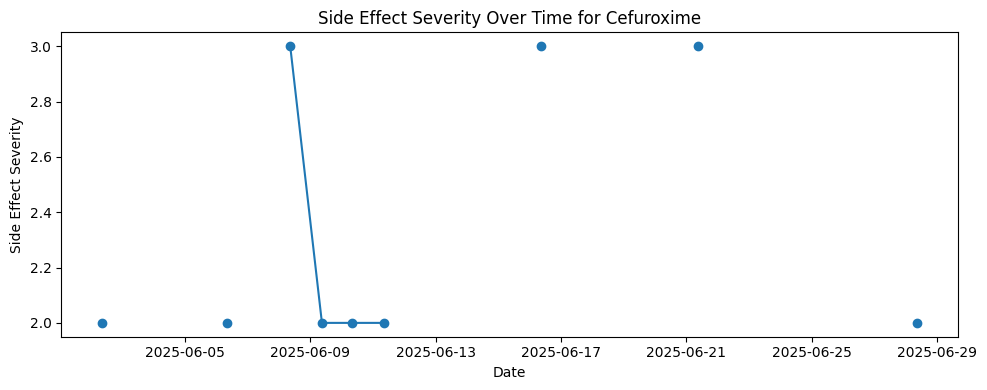

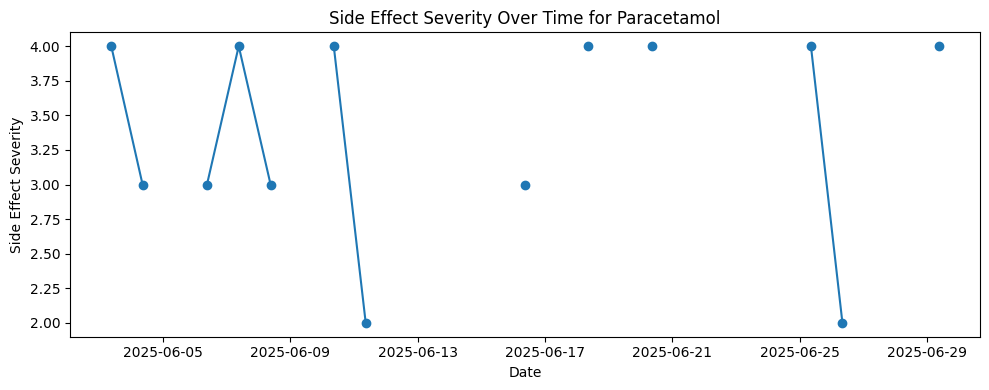

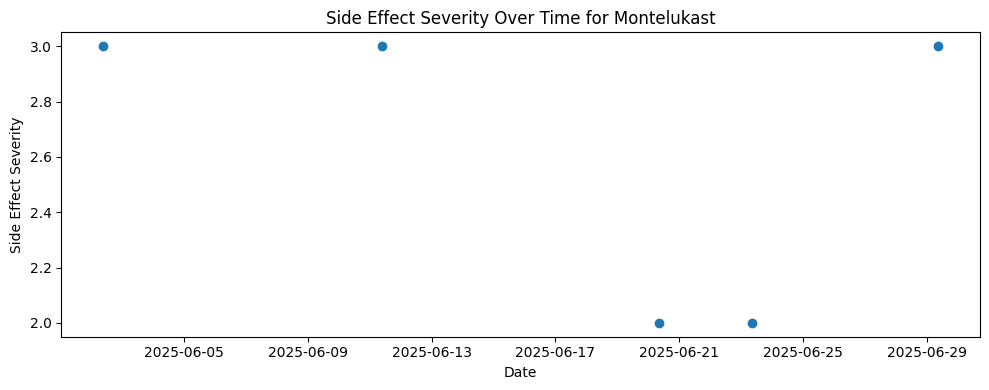

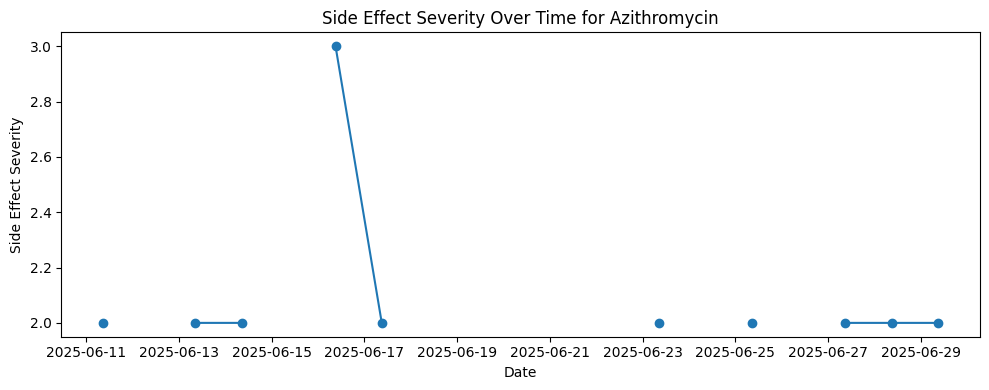

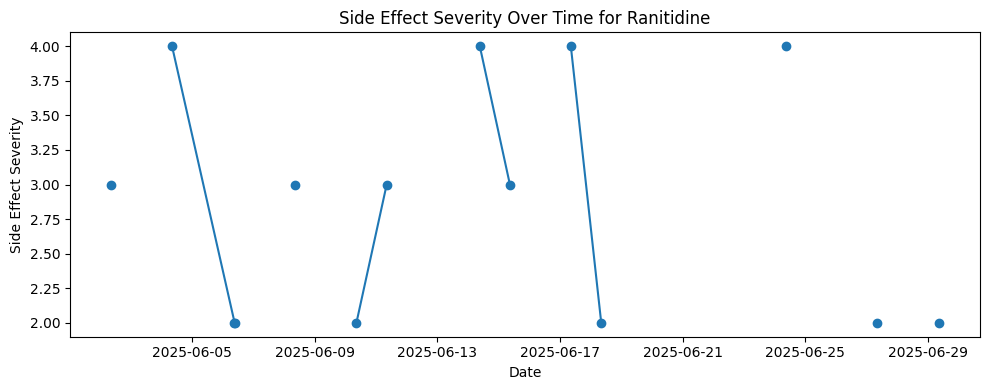

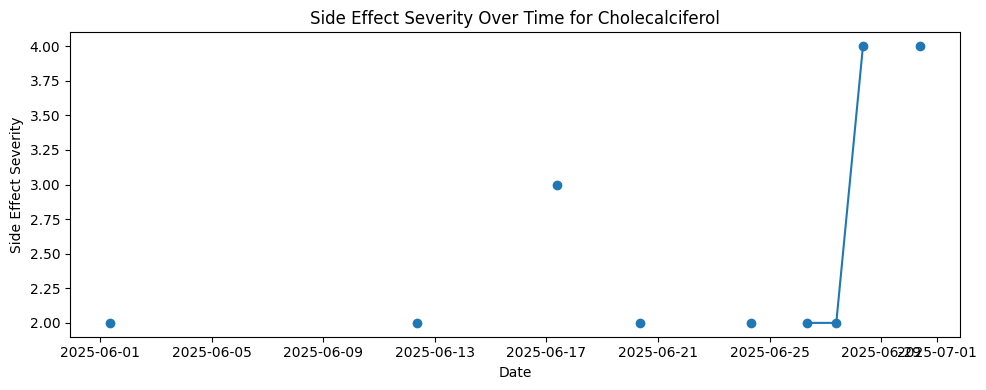

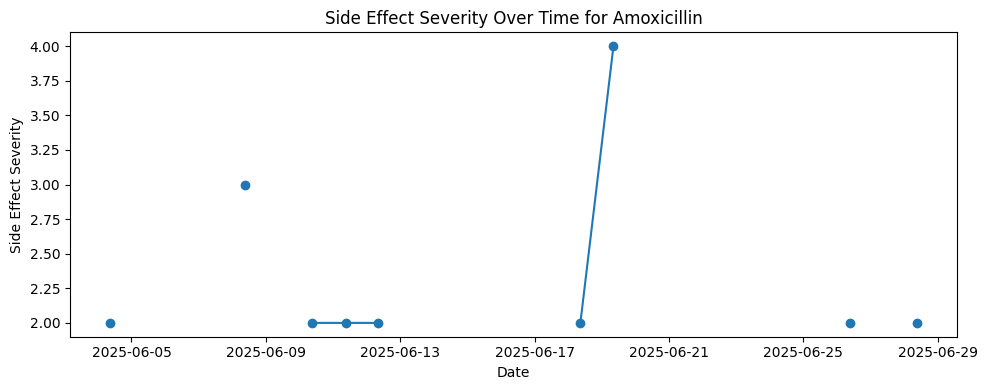

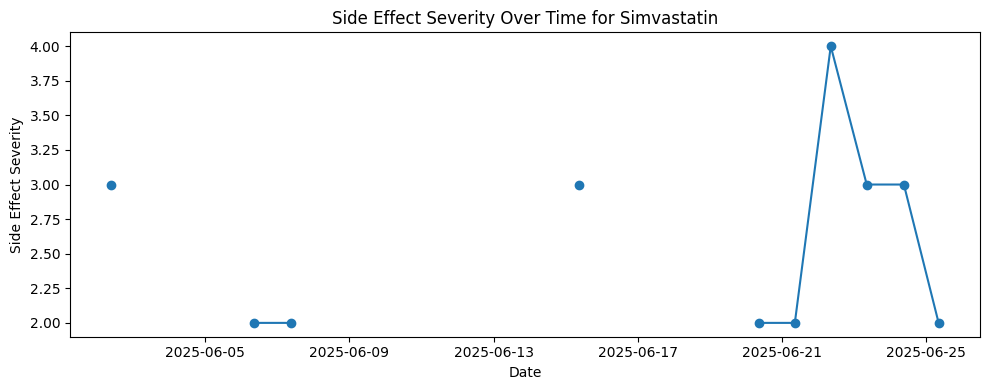

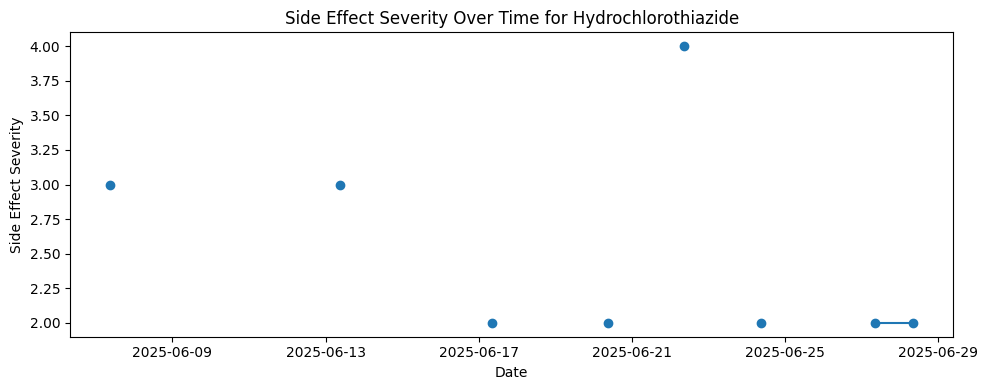

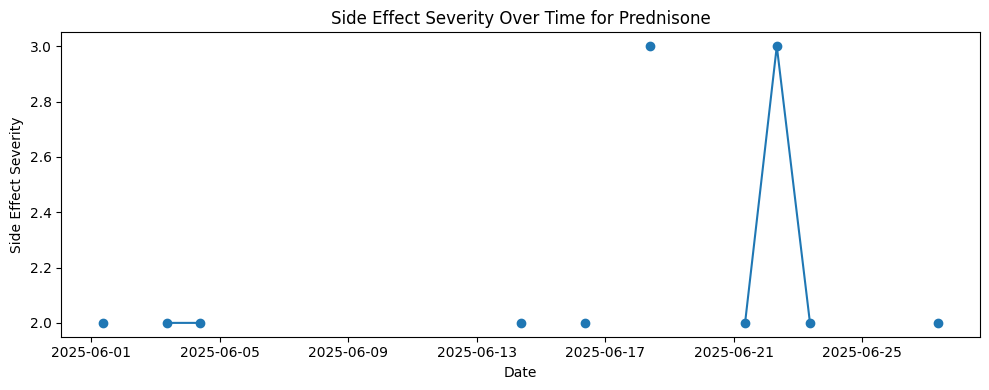

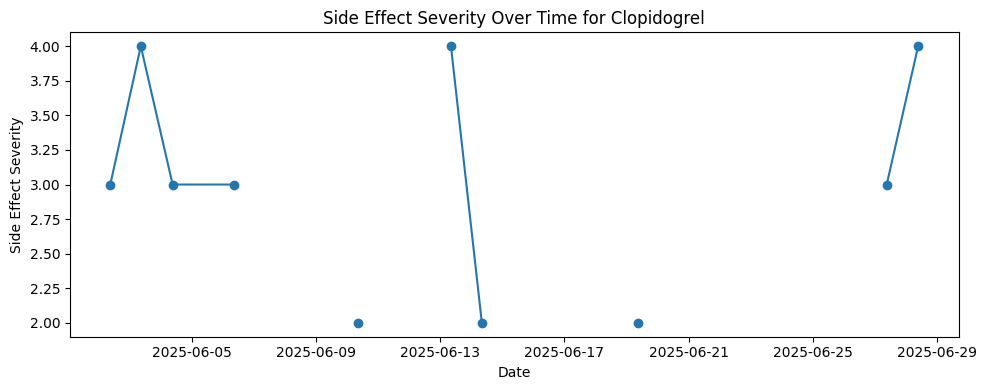

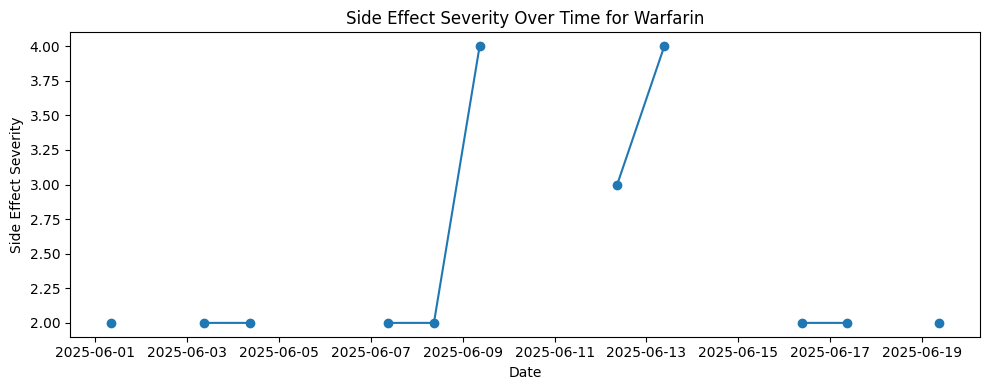

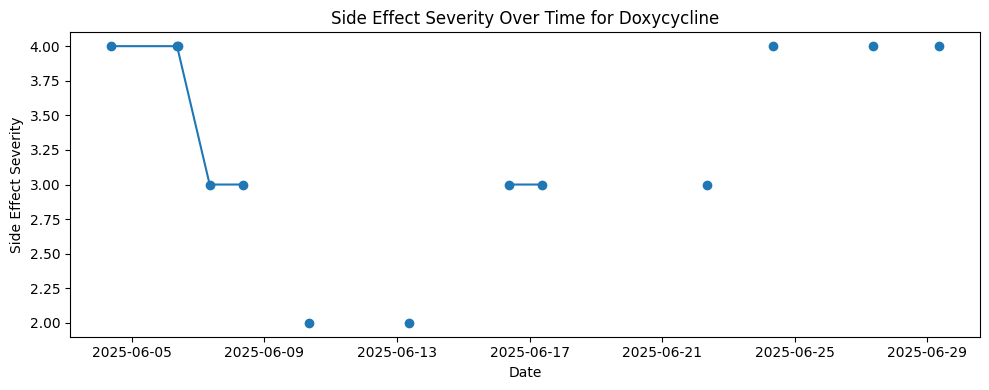

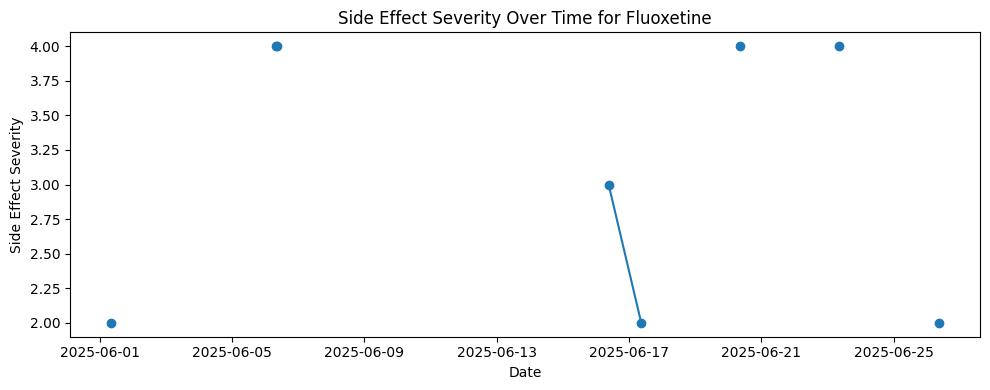

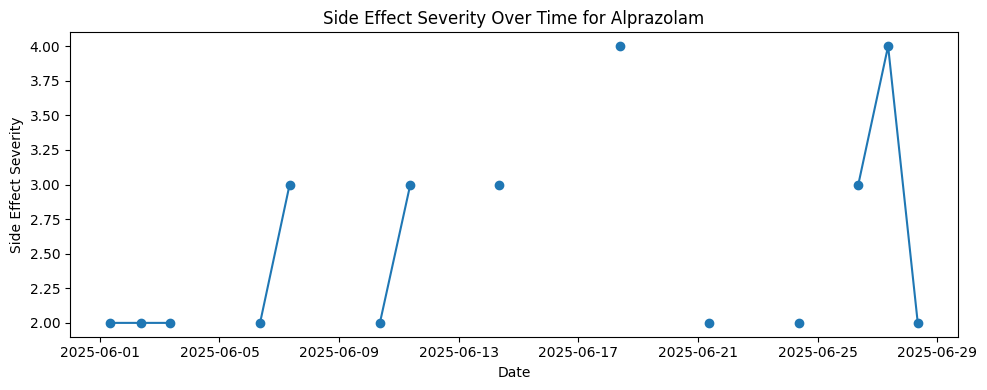

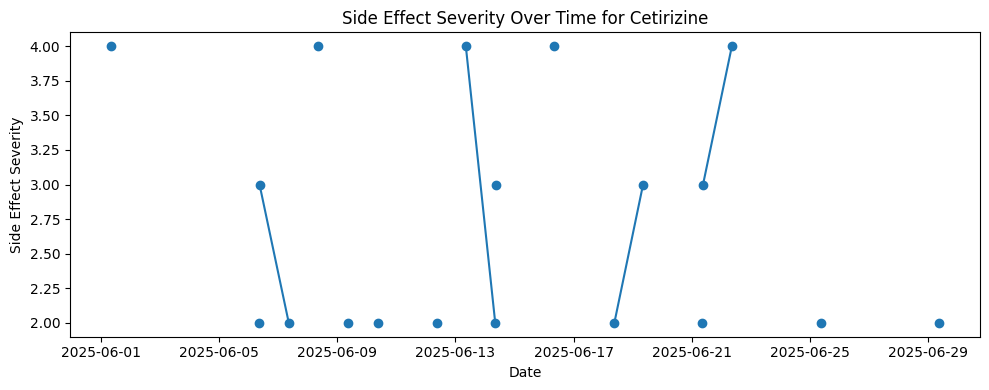

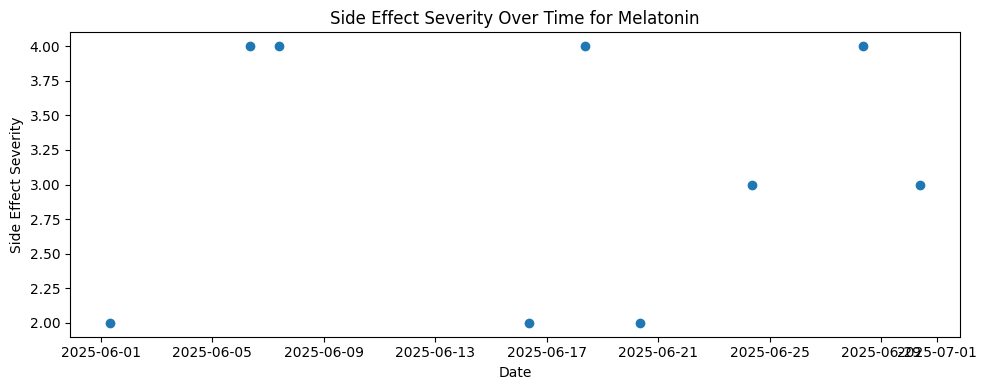

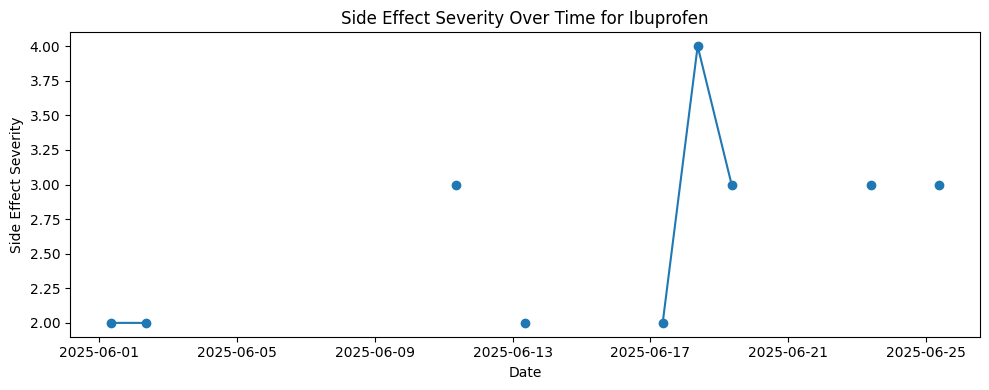

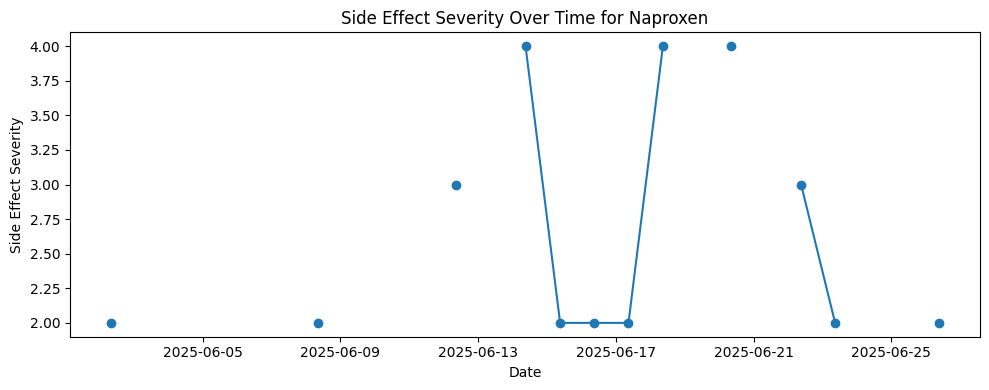

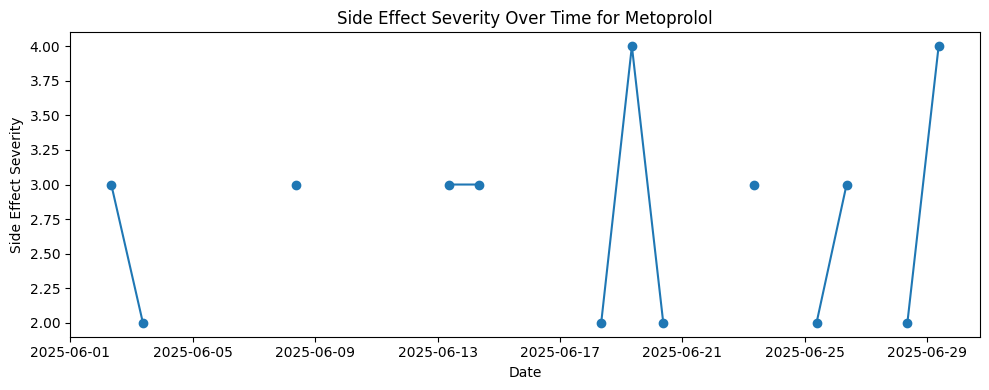

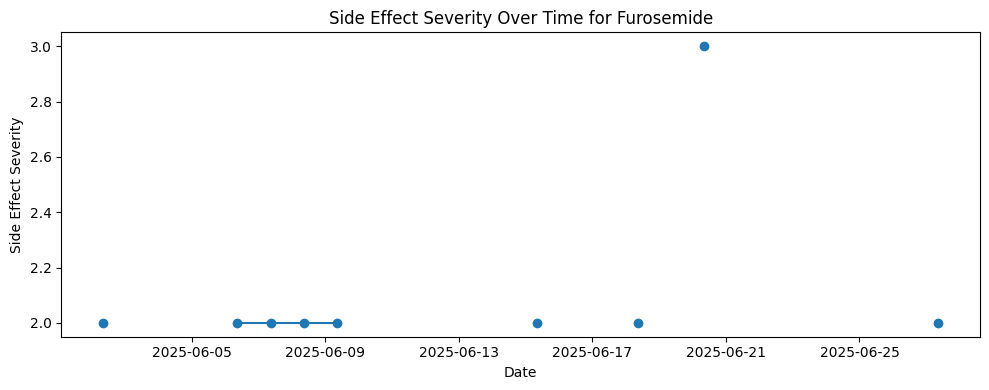

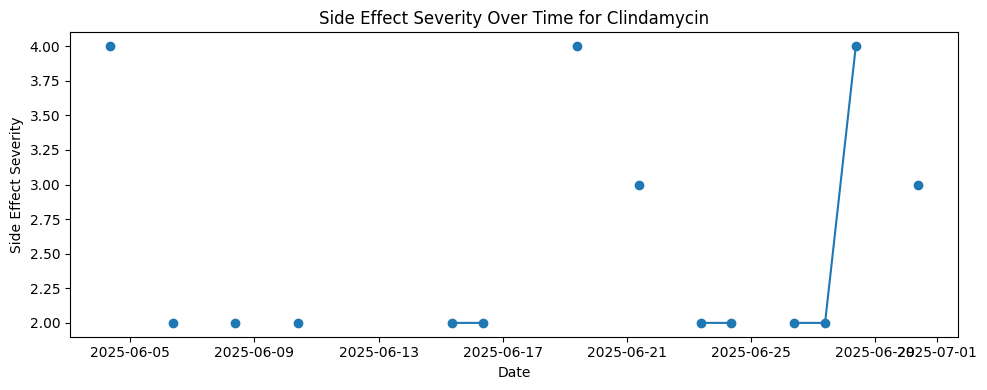

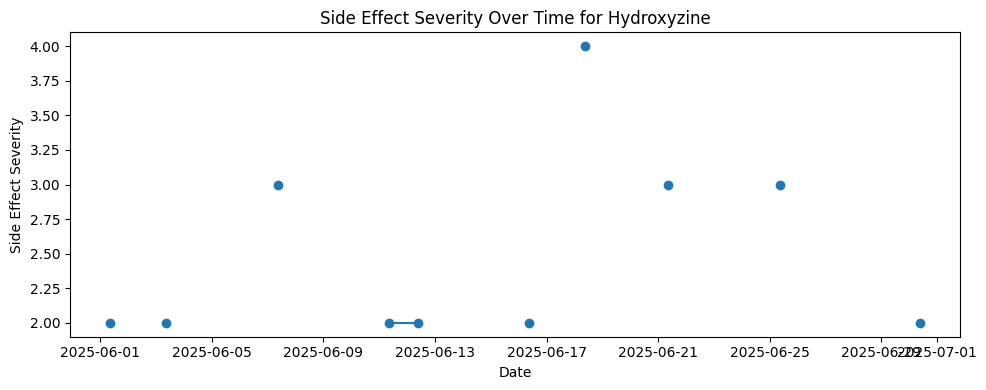

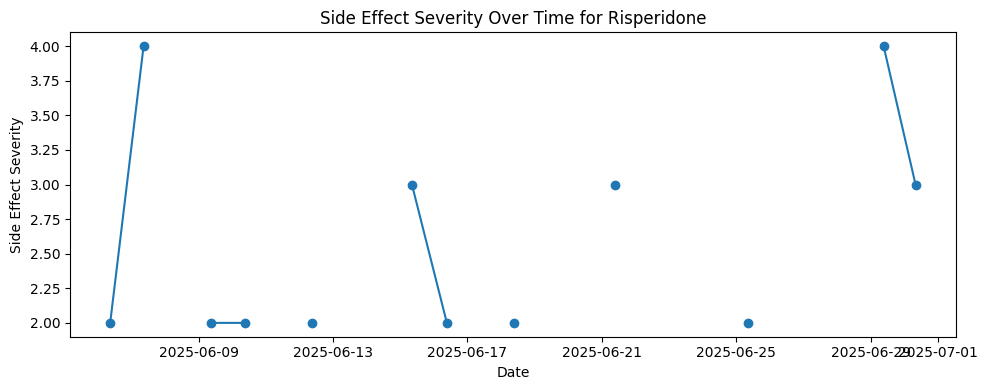

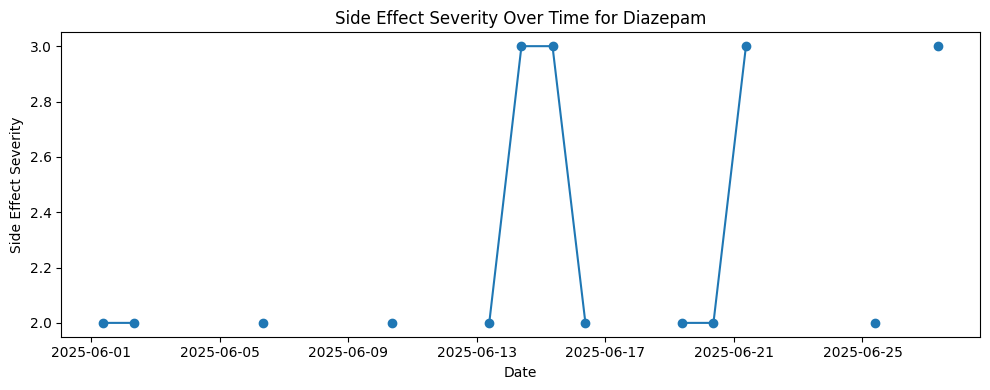

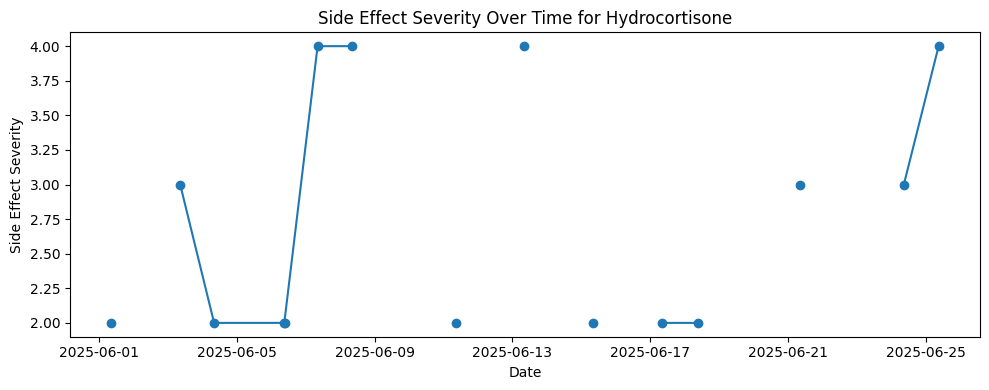

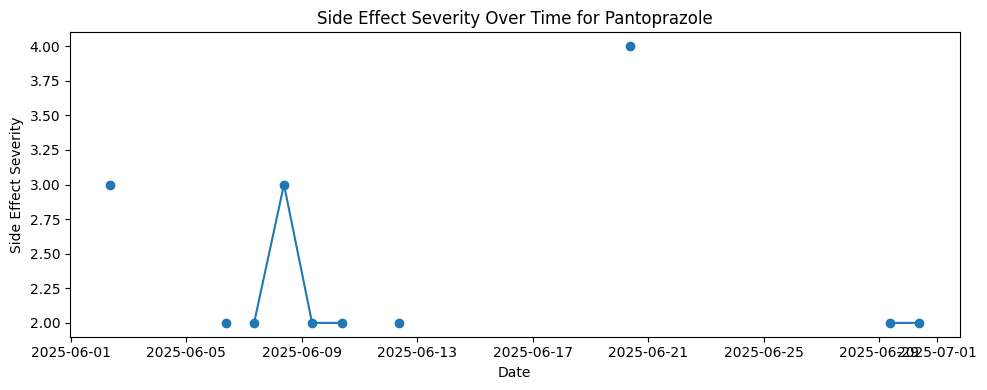

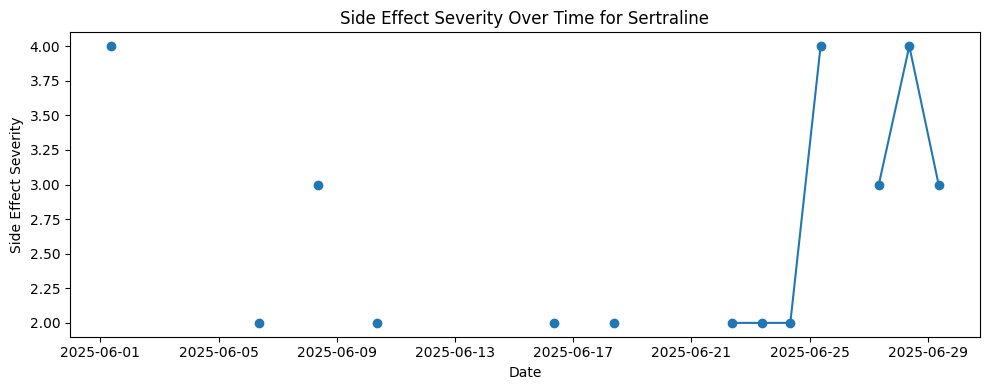

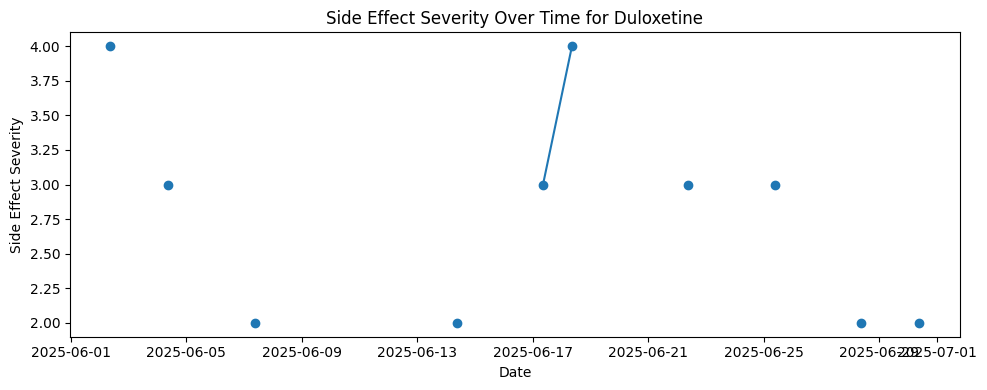

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load medication logs and medication names
df = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')

# Merge to get medication names
df = df.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')

# Convert 'logged_at' to datetime and 'side_effects__severity' to numeric
df['logged_at'] = pd.to_datetime(df['logged_at'], errors='coerce')
df['side_effects__severity'] = pd.to_numeric(df['side_effects__severity'], errors='coerce')

# Get all unique medication names
med_names = df['title'].dropna().unique()

# Generate and save plots for each medication
for med in med_names:
    df_med = df[df['title'] == med]
    if df_med['side_effects__severity'].notna().sum() == 0:
        continue  # Skip if no side effect data
    plt.figure(figsize=(10,4))
    plt.plot(df_med['logged_at'], df_med['side_effects__severity'], marker='o')
    plt.title(f'Side Effect Severity Over Time for {med}')
    plt.xlabel('Date')
import pandas as pd
import matplotlib.pyplot as plt

# Load medication logs and medication names
df = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')

# Merge to get medication names
df = df.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')

# Convert 'logged_at' to datetime and 'side_effects__severity' to numeric
df['logged_at'] = pd.to_datetime(df['logged_at'], errors='coerce')
df['side_effects__severity'] = pd.to_numeric(df['side_effects__severity'], errors='coerce')

# Get all unique medication names
med_names = df['title'].dropna().unique()

# Generate and save plots for each medication
for med in med_names:
    df_med = df[df['title'] == med]
    if df_med['side_effects__severity'].notna().sum() == 0:
        continue  # Skip if no side effect data
    plt.figure(figsize=(10,4))
    plt.plot(df_med['logged_at'], df_med['side_effects__severity'], marker='o')
    plt.title(f'Side Effect Severity Over Time for {med}')
    plt.xlabel('Date')
    plt.ylabel('Side Effect Severity')
    plt.tight_layout()
    fname = f'side_effect_severity_{med.replace(" ", "_").replace("/", "_")}.png'
    plt.show()
    plt.savefig(fname)
    plt.close()


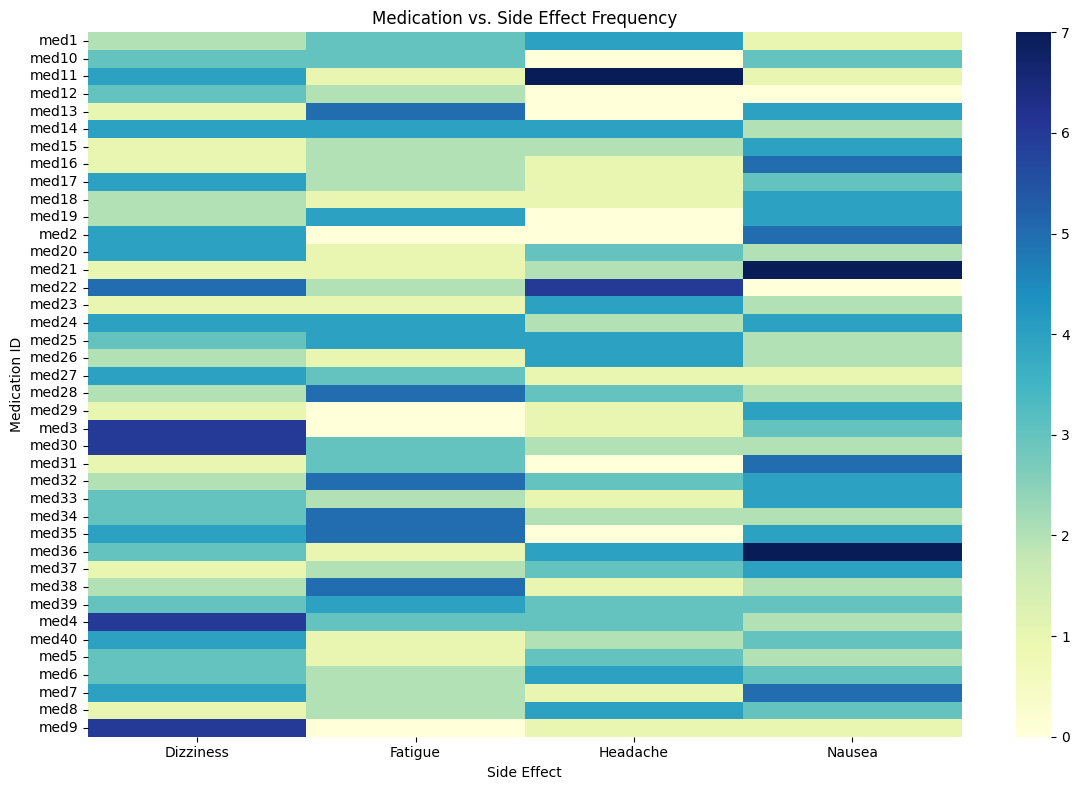

In [21]:

med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')
heatmap_data = med_logs.groupby(['medicationId', 'side_effects__description']).size().unstack(fill_value=0)
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Medication vs. Side Effect Frequency')
plt.xlabel('Side Effect')
plt.ylabel('Medication ID')
plt.tight_layout()
plt.show()


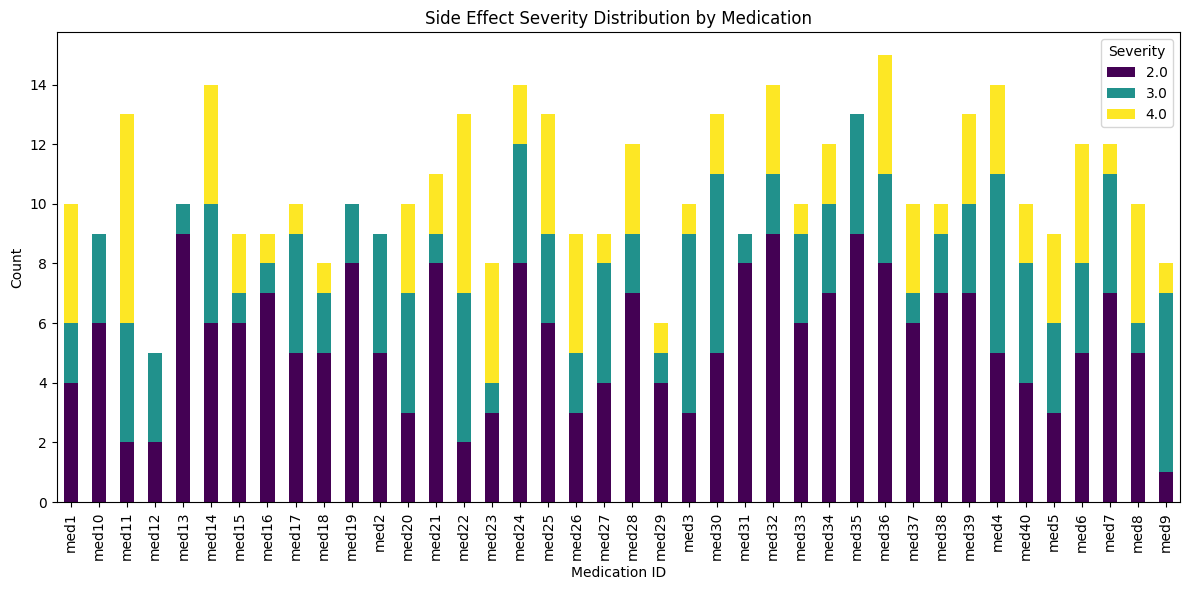

In [22]:
severity_dist = med_logs.groupby(['medicationId', 'side_effects__severity']).size().unstack(fill_value=0)
severity_dist = severity_dist[[1,2,3]] if set([1,2,3]).issubset(severity_dist.columns) else severity_dist
severity_dist.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.title('Side Effect Severity Distribution by Medication')
plt.xlabel('Medication ID')
plt.ylabel('Count')
plt.legend(title='Severity')
plt.tight_layout()
plt.show()


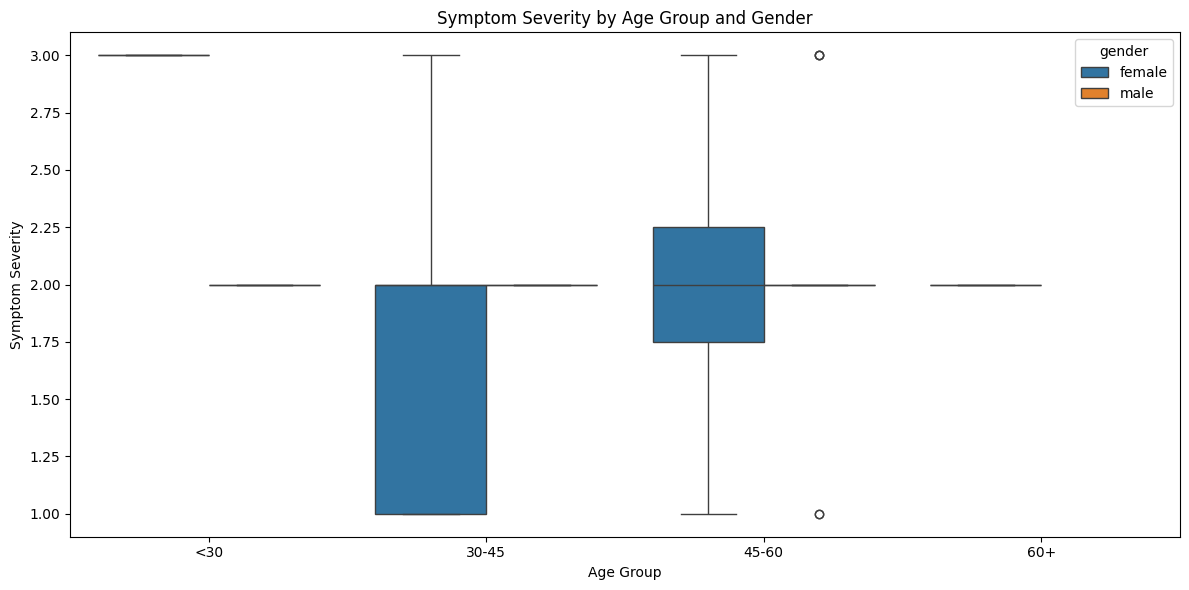

In [23]:
symptoms = pd.read_csv('symptoms.csv')
patients = pd.read_csv('patients.csv')
symptoms['severity_num'] = symptoms['severity'].map({'mild':1, 'moderate':2, 'severe':3})
symp_pat = symptoms.merge(patients, on='patientId', how='left')
symp_pat['age_group'] = pd.cut(symp_pat['patient_age'], bins=[0,30,45,60,100], labels=['<30','30-45','45-60','60+'])
plt.figure(figsize=(12,6))
sns.boxplot(x='age_group', y='severity_num', hue='gender', data=symp_pat)
plt.title('Symptom Severity by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Symptom Severity')
plt.tight_layout()
plt.show()


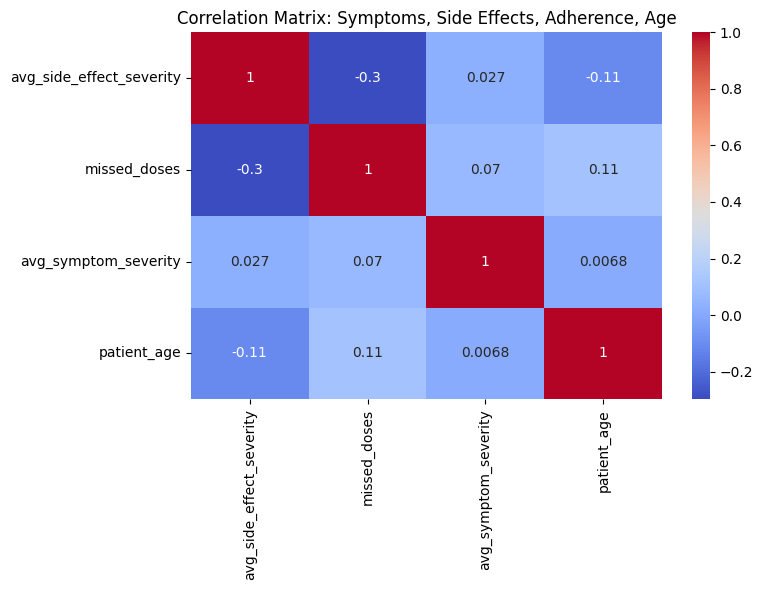

In [24]:
# Aggregate per patient
med_agg = med_logs.groupby('patientId').agg(
    avg_side_effect_severity=('side_effects__severity', 'mean'),
    missed_doses=('status', lambda x: (x=='missed').sum())
).reset_index()
symp_agg = symptoms.groupby('patientId').agg(
    avg_symptom_severity=('severity_num', 'mean')
).reset_index()
summary = med_agg.merge(symp_agg, on='patientId', how='outer')
summary = summary.merge(patients[['patientId', 'patient_age']], on='patientId', how='left')
summary.fillna(0, inplace=True)
corr = summary[['avg_side_effect_severity', 'missed_doses', 'avg_symptom_severity', 'patient_age']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Symptoms, Side Effects, Adherence, Age')
plt.tight_layout()
plt.show()


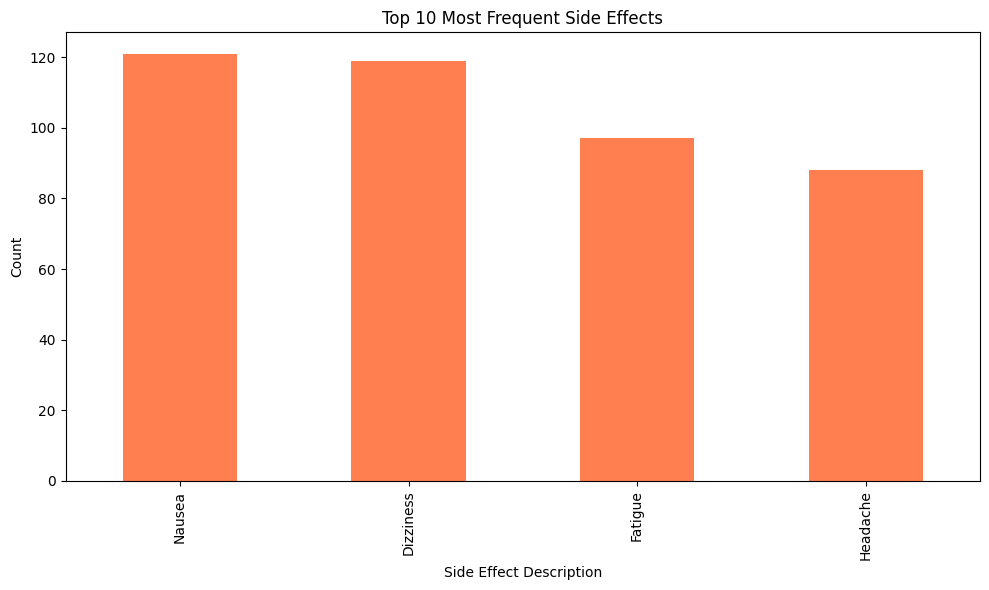

In [25]:
side_effect_counts = med_logs.groupby('side_effects__description').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
side_effect_counts.plot(kind='bar', color='coral')
plt.title('Top 10 Most Frequent Side Effects')
plt.xlabel('Side Effect Description')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


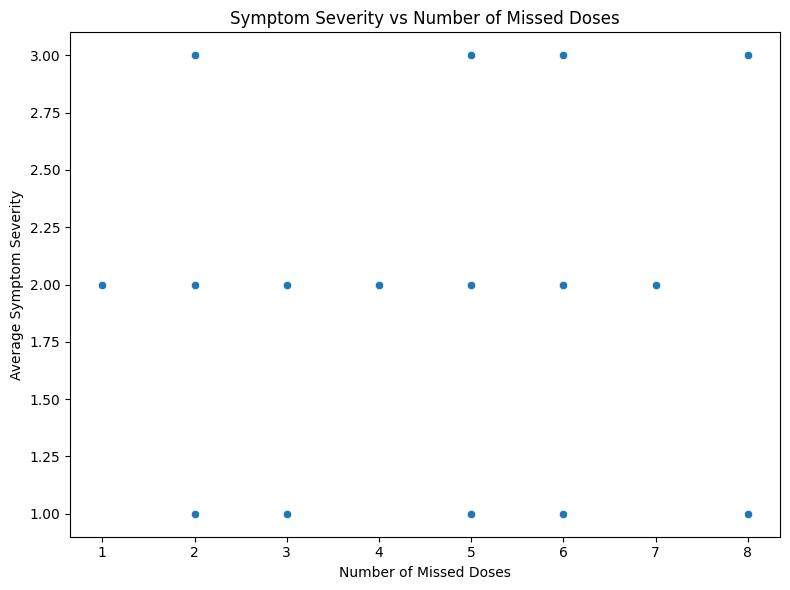

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=summary['missed_doses'], y=summary['avg_symptom_severity'])
plt.title('Symptom Severity vs Number of Missed Doses')
plt.xlabel('Number of Missed Doses')
plt.ylabel('Average Symptom Severity')
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
import plotly.express as px

# Load data
med_logs = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')
med_logs = med_logs.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')
med_logs['logged_at'] = pd.to_datetime(med_logs['logged_at'], errors='coerce')
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')

fig = px.scatter(
    med_logs[med_logs['side_effects__severity'].notna()],
    x='logged_at',
    y='side_effects__severity',
    color='title',
    hover_data=['patientId', 'side_effects__description', 'side_effects__notes'],
    title="Interactive Side Effect Severity Timeline (All Medications)",
    labels={'logged_at': 'Date', 'side_effects__severity': 'Severity', 'title': 'Medication'}
)
fig.update_traces(mode='lines+markers')
fig.show()


In [34]:
import plotly.express as px

symptoms = pd.read_csv('symptoms.csv')
diet_logs = pd.read_csv('diet_logs.csv')
dietPlans = pd.read_csv('dietPlans.csv')
patients = pd.read_csv('patients.csv')

# Map severity to numeric
severity_map = {'mild': 1, 'moderate': 2, 'severe': 3}
symptoms['severity_num'] = symptoms['severity'].map(severity_map)
symptoms = symptoms.merge(patients[['patientId', 'patient_name']], on='patientId', how='left')
diet_logs = diet_logs.merge(dietPlans[['description', 'assignedTo']], left_on=['diet_plan', 'patientId'], right_on=['description', 'assignedTo'], how='left')

# Merge symptoms with diet logs by patient and date
symptoms['dateReported'] = pd.to_datetime(symptoms['dateReported'], format='%d-%m-%Y', errors='coerce')
diet_logs['date'] = pd.to_datetime(diet_logs['date'], format='%d-%m-%Y', errors='coerce')
symptom_diet = pd.merge(symptoms, diet_logs, left_on=['patientId', 'dateReported'], right_on=['patientId', 'date'], how='left')

fig = px.box(
    symptom_diet,
    x='diet_plan',
    y='severity_num',
    points='all',
    hover_data=['patient_name', 'symptom1', 'symptoms2', 'symptoms3'],
    title="Symptom Severity by Diet Plan"
)
fig.update_layout(xaxis_title="Diet Plan", yaxis_title="Symptom Severity")
fig.show()


In [40]:
import pandas as pd
import plotly.express as px

# Load data
med_logs = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')
med_logs = med_logs.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')
med_logs['logged_at'] = pd.to_datetime(med_logs['logged_at'], errors='coerce')
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')

fig = px.scatter(
    med_logs[med_logs['side_effects__severity'].notna()],
    x='logged_at',
    y='side_effects__severity',
    color='title',
    hover_data=['patientId', 'side_effects__description', 'side_effects__notes'],
    title="Interactive Side Effect Severity Timeline (All Medications)",
    labels={'logged_at': 'Date', 'side_effects__severity': 'Severity', 'title': 'Medication'}
)
fig.update_traces(mode='lines+markers')
fig.show()


In [37]:
import pandas as pd
import plotly.express as px

# Load and preprocess
symptoms = pd.read_csv('symptoms.csv')
patients = pd.read_csv('patients.csv')
symptoms['dateReported'] = pd.to_datetime(symptoms['dateReported'], format='%d-%m-%Y', errors='coerce')
severity_map = {'mild': 1, 'moderate': 2, 'severe': 3}
symptoms['severity_num'] = symptoms['severity'].map(severity_map)
symptoms = symptoms.merge(patients[['patientId', 'patient_name']], on='patientId', how='left')

fig = px.line(
    symptoms, x='dateReported', y='severity_num', color='patient_name',
    title='Symptom Severity Over Time by Patient',
    labels={'dateReported': 'Date', 'severity_num': 'Symptom Severity', 'patient_name': 'Patient'},
    markers=True
)
fig.show()


In [38]:
med_logs = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')
med_logs['logged_at'] = pd.to_datetime(med_logs['logged_at'], errors='coerce')
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')
med_logs = med_logs.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')

fig = px.scatter(
    med_logs[med_logs['side_effects__severity'].notna()],
    x='logged_at', y='side_effects__severity', color='title',
    hover_data=['patientId', 'side_effects__description', 'side_effects__notes'],
    title='Side Effect Severity Over Time by Medication',
    labels={'logged_at': 'Date', 'side_effects__severity': 'Severity', 'title': 'Medication'}
)
fig.show()


In [39]:
heatmap_data = med_logs.groupby(['title', 'side_effects__description']).size().reset_index(name='count')
fig = px.density_heatmap(
    heatmap_data, x='side_effects__description', y='title', z='count',
    color_continuous_scale='YlOrRd',
    title='Frequency of Side Effects by Medication'
)
fig.show()


In [42]:
import pandas as pd
import plotly.express as px

# Load data
med_logs = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')
med_logs = med_logs.merge(medications[['medicationsId', 'title']], left_on='medicationId', right_on='medicationsId', how='left')

# Convert 'logged_at' to datetime and 'side_effects__severity' to numeric
med_logs['logged_at'] = pd.to_datetime(med_logs['logged_at'], errors='coerce')
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')

# Fill missing values in the columns used for the sunburst path
# This prevents the 'None entries cannot have not-None children' error
med_logs['title'] = med_logs['title'].fillna('Unknown Medication')
med_logs['side_effects__description'] = med_logs['side_effects__description'].fillna('No Side Effect Reported')
# patientId is unlikely to be null if present in med_logs, but we can fill it just in case
med_logs['patientId'] = med_logs['patientId'].fillna('Unknown Patient')


fig = px.sunburst(
    med_logs, path=['title', 'side_effects__description', 'patientId'],
    values=None, # Keep values=None to count occurrences
    title='Side Effects by Medication and Patient'
)
fig.show()

In [44]:
diet_logs = pd.read_csv('diet_logs.csv')
dietPlans = pd.read_csv('dietPlans.csv')
diet_logs = diet_logs.merge(dietPlans[['description', 'assignedTo']], left_on=['diet_plan', 'patientId'], right_on=['description', 'assignedTo'], how='left')
symptoms_diet = symptoms.merge(diet_logs, on='patientId', how='left')

fig = px.box(
    symptoms_diet, x='diet_plan', y='severity_num', points='all',
    hover_data=['patient_name', 'symptom1', 'symptoms2', 'symptoms3'],
    title='Symptom Severity by Diet Plan'
)
fig.show()


In [50]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
med_logs = pd.read_csv('corrected_medication_logs.csv')
medications = pd.read_csv('medications.csv')
diet_logs = pd.read_csv('diet_logs.csv')
dietPlans = pd.read_csv('dietPlans.csv')
patients = pd.read_csv('patients.csv')

# Add medication name
med_logs = med_logs.merge(medications[['medicationsId', 'title', 'assignedTo']], left_on=['medicationId', 'patientId'], right_on=['medicationsId', 'assignedTo'], how='left')

# Add diet plan description (for each patient, use their assigned diet from dietPlans)
med_logs = med_logs.merge(dietPlans[['assignedTo', 'description']], left_on='patientId', right_on='assignedTo', how='left', suffixes=('', '_diet'))

# Add patient age and gender
med_logs = med_logs.merge(patients[['patientId', 'patient_age', 'gender']], on='patientId', how='left')


In [51]:
med_logs['side_effects__severity'] = pd.to_numeric(med_logs['side_effects__severity'], errors='coerce')
med_logs['severe_side_effect'] = (med_logs['side_effects__severity'] >= 3).astype(int)


In [52]:
le_med = LabelEncoder()
le_diet = LabelEncoder()
le_gender = LabelEncoder()

# Fill missing with a string (LabelEncoder can't handle NaN)
med_logs['title'] = med_logs['title'].fillna('Unknown')
med_logs['description'] = med_logs['description'].fillna('Unknown')
med_logs['gender'] = med_logs['gender'].fillna('Unknown')

med_logs['med_code'] = le_med.fit_transform(med_logs['title'])
med_logs['diet_code'] = le_diet.fit_transform(med_logs['description'])
med_logs['gender_code'] = le_gender.fit_transform(med_logs['gender'])


In [53]:
# patient_age may still have missing values, fill with median or 0
med_logs['patient_age'] = med_logs['patient_age'].fillna(med_logs['patient_age'].median())

X = med_logs[['med_code', 'diet_code', 'patient_age', 'gender_code']]
y = med_logs['severe_side_effect']


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      1.00      0.91       248
           1       0.00      0.00      0.00        52

    accuracy                           0.83       300
   macro avg       0.41      0.50      0.45       300
weighted avg       0.68      0.83      0.75       300



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [55]:
from imblearn.over_sampling import SMOTE

X_resampled, y_resampled = SMOTE().fit_resample(X_train, y_train)
clf = RandomForestClassifier(random_state=42).fit(X_resampled, y_resampled)


In [56]:
clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [57]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.58      0.68       248
           1       0.17      0.40      0.24        52

    accuracy                           0.55       300
   macro avg       0.49      0.49      0.46       300
weighted avg       0.71      0.55      0.60       300



In [58]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.62      0.71       248
           1       0.17      0.37      0.23        52

    accuracy                           0.58       300
   macro avg       0.50      0.49      0.47       300
weighted avg       0.71      0.58      0.63       300



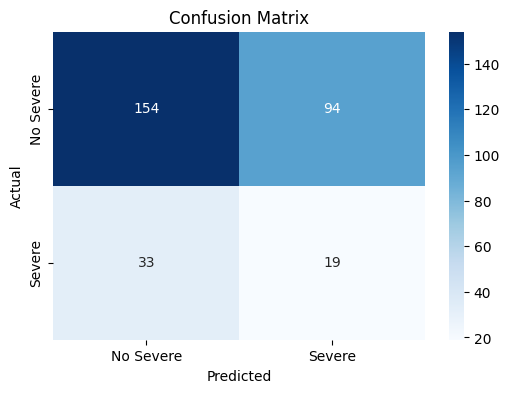

<ipython-input-61-a82a4d61db48>:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




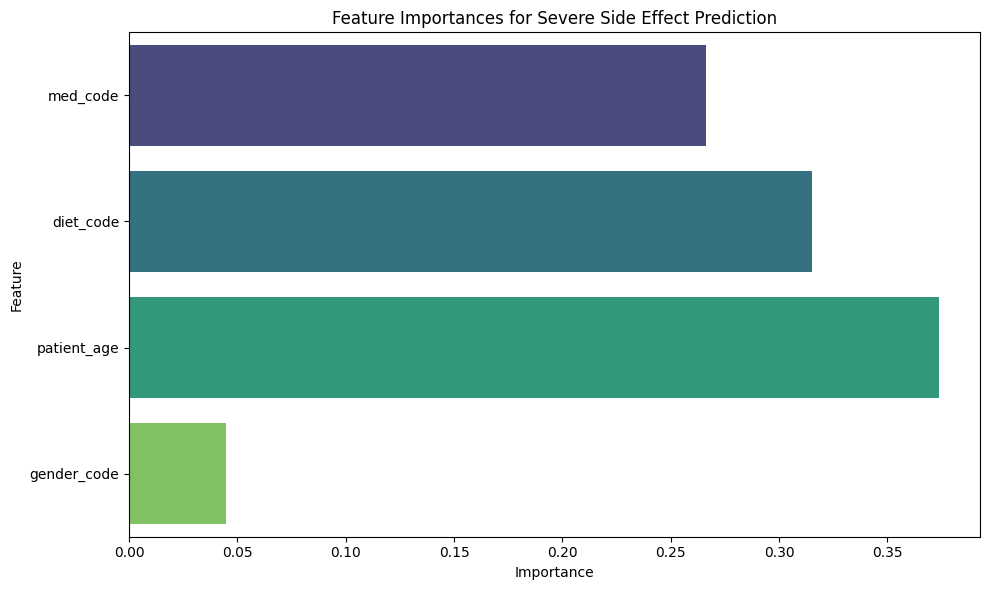

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest on resampled data
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=8  # Prevent overfitting
)
rf.fit(X_res, y_res)

# Predictions
y_pred = rf.predict(X_test)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Severe', 'Severe'],
            yticklabels=['No Severe', 'Severe'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title('Feature Importances for Severe Side Effect Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [64]:
import xgboost as xgb

model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    objective='binary:logistic',
    eval_metric='aucpr'  # Optimize for precision-recall curve
)
model.fit(X_res, y_res)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [65]:
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# 2. Handle imbalance with SMOTETomek
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)

# 3. Train XGBoost with scale_pos_weight
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_res, y_res)

# 4. Predict and evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
report = classification_report(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(report)
print("Confusion matrix:\n", cm)


              precision    recall  f1-score   support

           0       0.86      0.27      0.41       298
           1       0.18      0.79      0.30        62

    accuracy                           0.36       360
   macro avg       0.52      0.53      0.36       360
weighted avg       0.75      0.36      0.39       360

Confusion matrix:
 [[ 81 217]
 [ 13  49]]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[17:34:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


